# <center>APRENDIZAJE NO SUPERVISADO (DengAI)<center>

**Nombre y apellidos: Pablo Sáez Gil**

---
# Resumen
---

## Resumen

En esta práctica se desarrolla un estudio de análisis exploratorio y segmentación no supervisada de datos meteorológicos asociados a la propagación del dengue, empleando el conjunto de datos de la competición **[DengAI: Predicting Disease Spread](https://www.drivendata.org/competitions/44/dengai-predicting-disease-spread/)** de DrivenData.

El propósito general es **identificar patrones climáticos semanales** en las ciudades de **San Juan** (Puerto Rico) e **Iquitos** (Perú), que puedan estar relacionados con la aparición o intensificación de brotes de dengue.

El trabajo se estructura en **cuatro fases principales**:

1. **Inicialización:** preparación del entorno de trabajo, carga del dataset y comprensión de su estructura general.  
2. **Exploración:** análisis descriptivo y visual de las variables, detección de valores atípicos y evaluación de la calidad de los datos.  
3. **Características:** tratamiento e imputación de valores faltantes, normalización, reducción de dimensionalidad mediante **PCA** y selección de las variables más relevantes.  
4. **Clustering:** aplicación y comparación de distintos algoritmos de agrupamiento —**Jerárquico**, **K-Means**, **DBSCAN** y **GMM (Mezclas Gaussianas)**— para descubrir patrones o regímenes climáticos.

Los resultados obtenidos muestran que los métodos **K-Means** y **GMM** ofrecen las agrupaciones más coherentes y estables, revelando **tres o cuatro regímenes climáticos principales en San Juan** y **una estructura más homogénea en Iquitos**.  
Estos hallazgos proporcionan una **base sólida para futuras tareas de aprendizaje supervisado**, orientadas a predecir el número de casos de dengue en función de las condiciones meteorológicas.


---
# Inicialización
---

In [2]:
# Imports generales
import pandas as pd
import io
from google.colab import files

seed = 42  # Semilla aleatoria arbitraria

def upload_files (index_fields=None):
  uploaded = files.upload()
  for fn in uploaded.keys():
    print('User uploaded file "{name}" with length {length} bytes'.format(
        name=fn, length=len(uploaded[fn])))
    df = pd.read_csv(io.StringIO(uploaded[fn].decode('utf-8')), index_col = index_fields)
    return df

In [4]:
# Subir el conjunto de entrenamiento sin variable objetivo (dengue_features_train.csv)
train = upload_files()
print(train.shape)
train.head()

Saving DengAI_Predicting_Disease_Spread_-_Training_Data_Features.csv to DengAI_Predicting_Disease_Spread_-_Training_Data_Features.csv
User uploaded file "DengAI_Predicting_Disease_Spread_-_Training_Data_Features.csv" with length 287139 bytes
(1456, 24)


,city,year,weekofyear,week_start_date,ndvi_ne,ndvi_nw,ndvi_se,ndvi_sw,precipitation_amt_mm,reanalysis_air_temp_k,...,reanalysis_precip_amt_kg_per_m2,reanalysis_relative_humidity_percent,reanalysis_sat_precip_amt_mm,reanalysis_specific_humidity_g_per_kg,reanalysis_tdtr_k,station_avg_temp_c,station_diur_temp_rng_c,station_max_temp_c,station_min_temp_c,station_precip_mm
0,sj,1990,18,1990-04-30,0.122600,0.103725,0.198483,0.177617,12.42,297.572857,...,32.00,73.365714,12.42,14.012857,2.628571,25.442857,6.900000,29.4,20.0,16.0
1,sj,1990,19,1990-05-07,0.169900,0.142175,0.162357,0.155486,22.82,298.211429,...,17.94,77.368571,22.82,15.372857,2.371429,26.714286,6.371429,31.7,22.2,8.6
2,sj,1990,20,1990-05-14,0.032250,0.172967,0.157200,0.170843,34.54,298.781429,...,26.10,82.052857,34.54,16.848571,2.300000,26.714286,6.485714,32.2,22.8,41.4
3,sj,1990,21,1990-05-21,0.128633,0.245067,0.227557,0.235886,15.36,298.987143,...,13.90,80.337143,15.36,16.672857,2.428571,27.471429,6.771429,33.3,23.3,4.0
4,sj,1990,22,1990-05-28,0.196200,0.262200,0.251200,0.247340,7.52,299.518571,...,12.20,80.460000,7.52,17.210000,3.014286,28.942857,9.371429,35.0,23.9,5.8


---
# Exploración
---

## Información del Dataset

Utilizamos el método **`train.info()`** para obtener una visión general del dataframe:

- **Número total de registros** y **columnas** presentes en el dataset.
- **Tipo de dato** de cada columna (numérico, objeto, etc.).
- Cantidad de **valores no nulos** en cada columna para detectar posibles **valores faltantes**.

In [5]:
print("Resumen de información del dataset:\n")
train.info()

Resumen de información del dataset:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1456 entries, 0 to 1455
Data columns (total 24 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   city                                   1456 non-null   object 
 1   year                                   1456 non-null   int64  
 2   weekofyear                             1456 non-null   int64  
 3   week_start_date                        1456 non-null   object 
 4   ndvi_ne                                1262 non-null   float64
 5   ndvi_nw                                1404 non-null   float64
 6   ndvi_se                                1434 non-null   float64
 7   ndvi_sw                                1434 non-null   float64
 8   precipitation_amt_mm                   1443 non-null   float64
 9   reanalysis_air_temp_k                  1446 non-null   float64
 10  reanalysis_avg_temp_k              

Adjuntamos la siguiente explicación de las variables:

**Indicadores de ciudad y fecha**

- city – Abreviatura de ciudad: sj for San Juan and iq for Iquitos
- week_start_date – Fecha dada en formato aaaa-mm-dd

**Datos climáticos diarios de la NOAA, mediciones de la estación meteorológica de los datos climáticos de la NOAA**

- station_max_temp_c – Temperatura máxima
- station_min_temp_c – Temperatura mínima
- station_avg_temp_c – Temperatura media
- station_precip_mm – Precipitación total
- station_diur_temp_rng_c – Rango de temperatura diurno

**Mediciones de precipitación por satélite PERSIANN (escala 0,25x0,25 grados)**

- precipitation_amt_mm – Precipitación total

**Mediciones de reanálisis del sistema de pronóstico climático NCEP de la NOAA (escala de 0,5x0,5 grados)**

- reanalysis_sat_precip_amt_mm – Precipitación total
- reanalysis_dew_point_temp_k – Temperatura media del punto de rocido
- reanalysis_air_temp_k – Temperatura media del aire
- reanalysis_relative_humidity_percent – Humedad relativa media
- reanalysis_specific_humidity_g_per_kg – Humedad específica media
- reanalysis_precip_amt_kg_per_m2 – Precipitación total
- reanalysis_max_air_temp_k – Temperatura máxima del aire
- reanalysis_min_air_temp_k – Temperatura mínima del aire
- reanalysis_avg_temp_k – Temperatura media del aire
- reanalysis_tdtr_k – Rango de temperatura diurno

**Vegetación satelital - Índice de vegetación de diferencia normalizada (NDVI) - Mediciones del índice de vegetación de diferencia normalizada CDR (escala de 0,5x0,5 grados) de la NOAA**

- ndvi_se – Píxel al sureste del centroide de la ciudad
- ndvi_sw – Píxel al suroeste del centroide de la ciudad
- ndvi_ne – Píxel al noreste del centroide de la ciudad
- ndvi_nw – Píxel al noroeste del centroide de la ciudad

## Estadísticas Descriptivas

Con **`train.describe()`** obtenemos un resumen estadístico de todas las variables numéricas del dataset:

- **Media**, **desviación estándar**, **mínimo** y **máximo** de cada variable.
- **Percentiles (25%, 50%, 75%)**, que nos permiten observar la dispersión y distribución de los datos.
- Detectamos posibles **outliers** cuando los valores máximos o mínimos se alejan mucho de los percentiles intermedios.

Este análisis es esencial para:
- Entender la **distribución general de los datos**,
- Identificar posibles **valores atípicos**,
- Tener un primer acercamiento a la **escala y rango** de cada característica antes de aplicar preprocesamiento.


In [6]:
print("Resumen de estadísticas descriptivas del dataset:\n")
train.describe()

Resumen de estadísticas descriptivas del dataset:



,year,weekofyear,ndvi_ne,ndvi_nw,ndvi_se,ndvi_sw,precipitation_amt_mm,reanalysis_air_temp_k,reanalysis_avg_temp_k,reanalysis_dew_point_temp_k,...,reanalysis_precip_amt_kg_per_m2,reanalysis_relative_humidity_percent,reanalysis_sat_precip_amt_mm,reanalysis_specific_humidity_g_per_kg,reanalysis_tdtr_k,station_avg_temp_c,station_diur_temp_rng_c,station_max_temp_c,station_min_temp_c,station_precip_mm
count,1456.000000,1456.000000,1262.000000,1404.000000,1434.000000,1434.000000,1443.000000,1446.000000,1446.000000,1446.000000,...,1446.000000,1446.000000,1443.000000,1446.000000,1446.000000,1413.000000,1413.000000,1436.000000,1442.000000,1434.000000
mean,2001.031593,26.503434,0.142294,0.130553,0.203783,0.202305,45.760388,298.701852,299.225578,295.246356,...,40.151819,82.161959,45.760388,16.746427,4.903754,27.185783,8.059328,32.452437,22.102150,39.326360
std,5.408314,15.019437,0.140531,0.119999,0.073860,0.083903,43.715537,1.362420,1.261715,1.527810,...,43.434399,7.153897,43.715537,1.542494,3.546445,1.292347,2.128568,1.959318,1.574066,47.455314
min,1990.000000,1.000000,-0.406250,-0.456100,-0.015533,-0.063457,0.000000,294.635714,294.892857,289.642857,...,0.000000,57.787143,0.000000,11.715714,1.357143,21.400000,4.528571,26.700000,14.700000,0.000000
25%,1997.000000,13.750000,0.044950,0.049217,0.155087,0.144209,9.800000,297.658929,298.257143,294.118929,...,13.055000,77.177143,9.800000,15.557143,2.328571,26.300000,6.514286,31.100000,21.100000,8.700000
50%,2002.000000,26.500000,0.128817,0.121429,0.196050,0.189450,38.340000,298.646429,299.289286,295.640714,...,27.245000,80.301429,38.340000,17.087143,2.857143,27.414286,7.300000,32.800000,22.200000,23.850000
75%,2005.000000,39.250000,0.248483,0.216600,0.248846,0.246982,70.235000,299.833571,300.207143,296.460000,...,52.200000,86.357857,70.235000,17.978214,7.625000,28.157143,9.566667,33.900000,23.300000,53.900000
max,2010.000000,53.000000,0.508357,0.454429,0.538314,0.546017,390.600000,302.200000,302.928571,298.450000,...,570.500000,98.610000,390.600000,20.461429,16.028571,30.800000,15.800000,42.200000,25.600000,543.300000


### Interpretación del Resumen Estadístico:

Con el análisis de las estadísticas descriptivas del dataset, hemos identificado los siguientes aspectos clave:

1. **Valores Faltantes**
  - Algunas variables presentan **menos registros** que el resto, destacando los índices de vegetación:
    - `ndvi_ne`: 1262 registros  
    - `ndvi_nw`: 1404 registros  
    - `ndvi_se`: 1434 registros
    - `ndvi_sw`: 1434 registros  
  - Esto sugiere la necesidad de **imputar valores faltantes** o, en ciertos casos, descartar filas incompletas.

2. **Valores Atípicos (Outliers)**
  - Se detectan **valores máximos extremadamente altos** en:
    - **Precipitación:** `precipitation_amt_mm` (390.6 mm), `station_precip_mm` (543.3 mm), `reanalysis_precip_amt_kg_per_m2` (570.5).  
    - **Rango térmico:** `reanalysis_tdtr_k` (16.02), notablemente mayor que su media (4.9).  
  - Estos picos indican **eventos climáticos extremos** o posibles **errores de registro** que requieren verificación y tratamiento.

3. **Distribuciones de las Variables**
  - **Temperatura media (`station_avg_temp_c`):**  
    - La mayoría de los valores se concentra entre **21,4°C y 30,8°C**, con mediana de 27.4°C → **clima cálido y estable**.  
  - **Precipitación y humedad relativa:**  
    - Presentan **distribuciones sesgadas**, con predominio de valores bajos (días secos) y algunos episodios de lluvias o humedad elevadas.  

4. **Percentiles**
  - El **percentil 75** de la temperatura media (`station_avg_temp_c`) es **28.15°C**, confirmando baja variabilidad térmica.  
  - En **precipitación**, el **P75 (53.9 mm)** es mucho menor que el máximo (543.3 mm), lo que refleja **lluvias intensas concentradas en pocos periodos**.

## Tratamiento de Valores Atípicos (Outliers)

Antes de proceder con el modelado, es necesario **identificar y analizar los outliers** presentes en las variables climáticas más relevantes.

En esta etapa:
- Vamos a **seleccionar las variables que mostraron valores extremos** en el análisis exploratorio (`describe()`)
- Realizaremos **visualizaciones comparativas por ciudad** para observar la dispersión y magnitud de estos valores.
- Este análisis inicial **no busca aún tomar decisiones**, sino comprender mejor el comportamiento de las variables y sentar las bases para el tratamiento posterior.

El objetivo de esta sección es preparar el terreno para decidir:
- Si los outliers corresponden a **eventos climáticos reales** que deben conservarse, o si representan **posibles errores de medición** que será necesario corregir o ajustar.




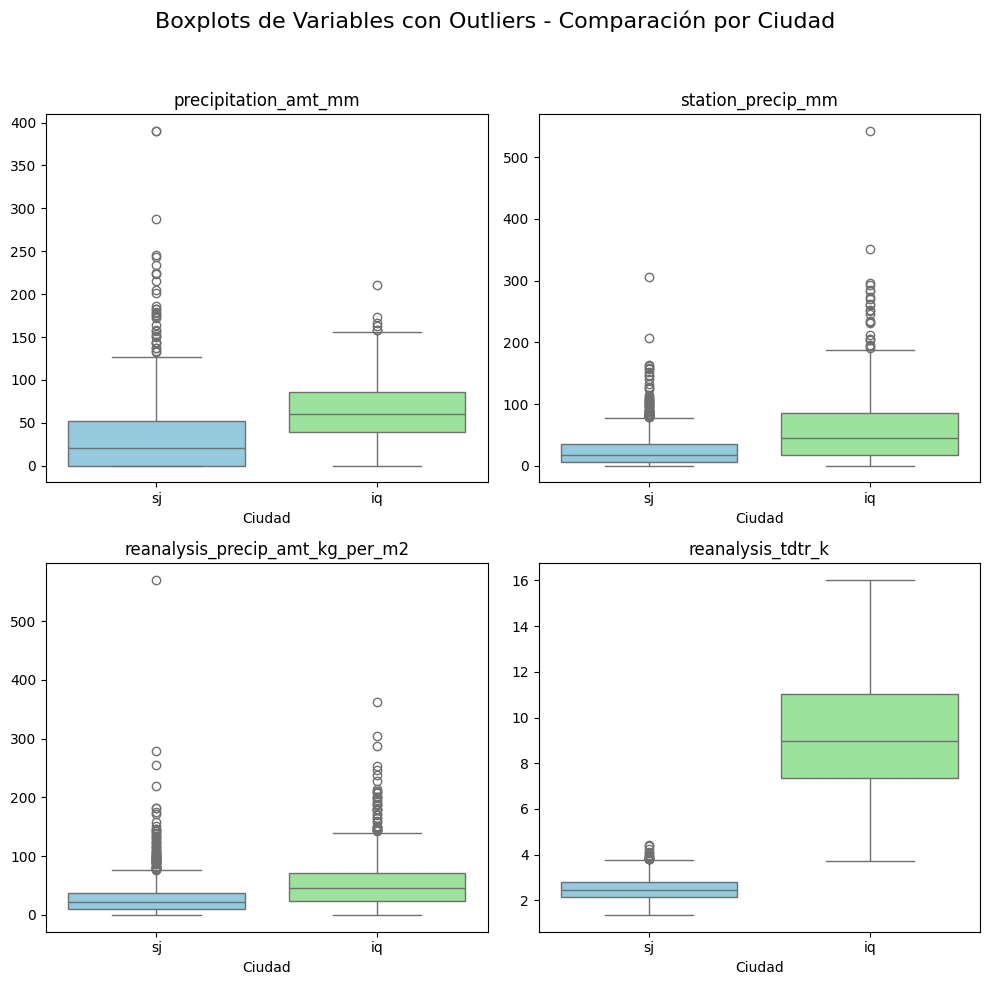

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

variables_outliers = [
    'precipitation_amt_mm',
    'station_precip_mm',
    'reanalysis_precip_amt_kg_per_m2',
    'reanalysis_tdtr_k'
]

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
fig.suptitle("Boxplots de Variables con Outliers - Comparación por Ciudad", fontsize=16)

axes = axes.flatten()

for ax, var in zip(axes, variables_outliers):
    sns.boxplot(
        x='city',
        y=var,
        hue='city',
        data=train,
        palette=['skyblue','lightgreen'],
        legend=False,
        ax=ax
    )
    ax.set_title(var, fontsize=12)
    ax.set_xlabel('Ciudad')
    ax.set_ylabel('')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


### Conclusión sobre los Outliers

El análisis de los **boxplots** para las variables con mayores valores extremos permitió caracterizar el comportamiento de cada ciudad:

- **Precipitación por satélite (`precipitation_amt_mm`):**  
  - En **San Juan**, la mayoría de los valores se concentra por debajo de **50 mm**, aunque se identifican picos que alcanzan los **390 mm**, indicando semanas puntuales de lluvias intensas.  
  - En **Iquitos**, la mediana es más elevada (≈40–50 mm) y los valores atípicos son más frecuentes, alcanzando hasta **200 mm**, lo que refleja un **clima tropical más lluvioso y variable**.

- **Precipitación en estación (`station_precip_mm`):**  
  - En **San Juan**, predomina la baja precipitación con pocos picos extremos.  
  - En **Iquitos**, los valores atípicos se acentúan, llegando incluso a superar los **500 mm**, evidenciando la mayor recurrencia de lluvias torrenciales en esta ciudad.

- **Precipitación según reanálisis (`reanalysis_precip_amt_kg_per_m2`):**  
  - Ambas ciudades presentan picos elevados, pero la **frecuencia e intensidad son mayores en Iquitos**, lo que sugiere que las condiciones locales favorecen episodios de lluvias extremas de forma más habitual.

- **Rango térmico diario (`reanalysis_tdtr_k`):**  
  - En **San Juan**, los valores se mantienen estables en torno a **2–4 K**, con pocos outliers.  
  - En **Iquitos**, se observa una distribución más amplia (≈5–12 K) con picos que alcanzan los **16 K**, indicando una **mayor variabilidad térmica diaria**, posiblemente asociada a factores meteorológicos de la región amazónica.

**Conclusión General:**  
Los valores atípicos detectados no parecen deberse a errores de medición, sino a **eventos climáticos reales y relevantes**, como lluvias torrenciales y variaciones térmicas puntuales.  
La **intensidad y frecuencia de los outliers es mayor en Iquitos**, especialmente en las variables relacionadas con la precipitación, mientras que **San Juan muestra un clima más seco y estable**.  
Estas diferencias confirman la importancia de **analizar y modelar cada ciudad por separado**, ya que los factores climáticos que influyen en la propagación del dengue presentan comportamientos claramente diferenciados entre ambas regiones.


## División del Dataset por Ciudad

El dataset original (`train`) contiene registros de **dos ciudades** con características climáticas muy distintas:

- **San Juan (sj)**: Clima tropical con marcada estacionalidad en lluvias.
- **Iquitos (iq)**: Región amazónica con altas precipitaciones y temperaturas más estables.

Dado que los patrones climáticos y las condiciones ambientales influyen de forma diferente en la propagación del dengue, es fundamental **tratar cada ciudad por separado**.  
Esto permite capturar las relaciones propias de cada región y evita mezclar distribuciones que podrían distorsionar el análisis y los modelos.

In [8]:
train_sj = train[train['city'] == 'sj']
train_iq = train[train['city'] == 'iq']

print("Registros de San Juan:", len(train_sj))
print("Registros de Iquitos:", len(train_iq))

Registros de San Juan: 936
Registros de Iquitos: 520


## Análisis de Valores Nulos

Antes de proceder al tratamiento de los datos, es fundamental **evaluar la cantidad de valores nulos** presentes en cada variable.  
Dado que el comportamiento de los registros puede diferir entre **San Juan** e **Iquitos**, se ha realizado el conteo de valores faltantes **por ciudad**.

### Objetivo
Este análisis inicial nos permitirá:
- Identificar las **variables críticas** con más valores nulos.
- Comprender si la falta de datos es un problema **global** o más acentuado en una de las dos ciudades.
- Definir posteriormente la **estrategia de imputación** más adecuada.

In [9]:
missing_sj = train_sj.isna().sum()
missing_iq = train_iq.isna().sum()

print("Valores faltantes en San Juan:\n", missing_sj)
print("\n")
print("Valores faltantes en Iquitos:\n", missing_iq)

Valores faltantes en San Juan:
 city                                       0
year                                       0
weekofyear                                 0
week_start_date                            0
ndvi_ne                                  191
ndvi_nw                                   49
ndvi_se                                   19
ndvi_sw                                   19
precipitation_amt_mm                       9
reanalysis_air_temp_k                      6
reanalysis_avg_temp_k                      6
reanalysis_dew_point_temp_k                6
reanalysis_max_air_temp_k                  6
reanalysis_min_air_temp_k                  6
reanalysis_precip_amt_kg_per_m2            6
reanalysis_relative_humidity_percent       6
reanalysis_sat_precip_amt_mm               9
reanalysis_specific_humidity_g_per_kg      6
reanalysis_tdtr_k                          6
station_avg_temp_c                         6
station_diur_temp_rng_c                    6
station_max_temp_c     

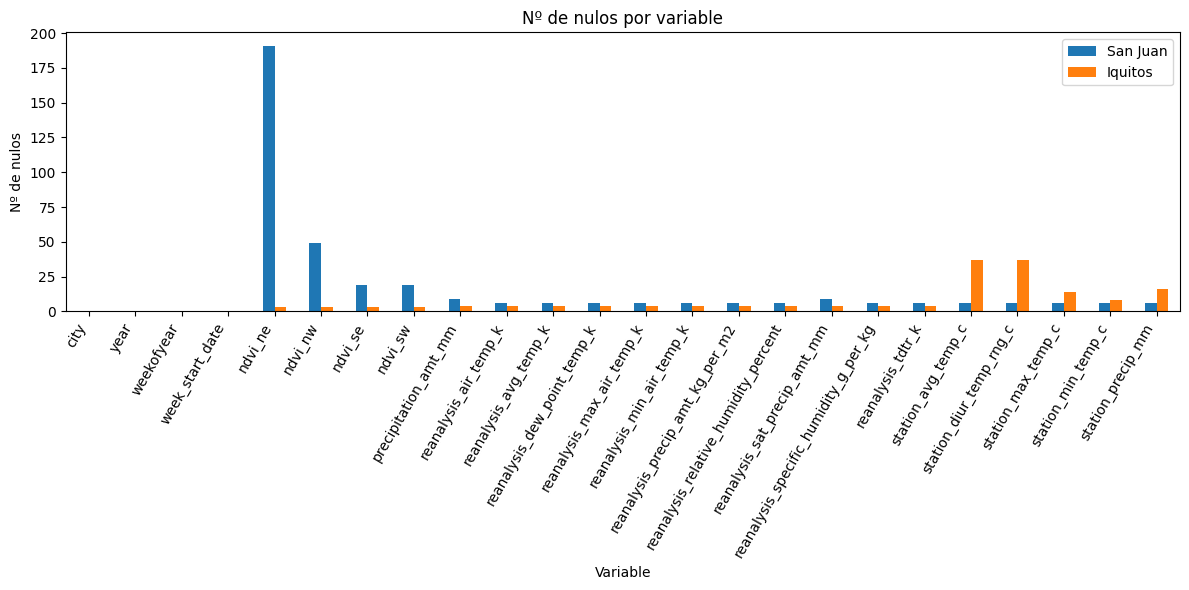

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Combinar en un DataFrame
train_missing = pd.DataFrame({
    "San Juan": missing_sj,
    "Iquitos": missing_iq
})


ax = train_missing.plot(kind="bar", figsize=(12,6))
ax.set_title("Nº de nulos por variable")
ax.set_xlabel("Variable")
ax.set_ylabel("Nº de nulos")
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()


### Resultados obtenidos

- **San Juan**
  - Las variables con más valores faltantes son las asociadas al **índice de vegetación NDVI**, especialmente:
    - `ndvi_ne` con **191 registros nulos**,  
    - seguido de `ndvi_nw` con **49 nulos**, y  
    - `ndvi_se` y `ndvi_sw` con **19 nulos** cada una.  
  - Otras variables (climáticas y de estación) presentan muy pocos valores nulos (≈6 a 9), lo que indica una cobertura bastante completa.

- **Iquitos**
  - La mayor proporción de valores faltantes se concentra en las variables de **mediciones en estaciones**:
    - `station_avg_temp_c` con **37 nulos**,  
    - `station_diur_temp_rng_c` con **37 nulos**,  
    - `station_precip_mm` con **16 nulos**,  
    - `station_max_temp_c` con **14 nulos**,  
    - `station_min_temp_c` con **8 nulos**.  
  - Las variables NDVI presentan muy pocos datos faltantes (solo **3 nulos** en cada subíndice).


##  Imputación de Valores Nulos con KNN

Tras identificar las variables con valores faltantes en ambas ciudades, se procedió a **imputar los valores nulos** para evitar la pérdida de información y asegurar la coherencia de los datos.

###  Estrategia aplicada
1. **Tratamiento separado por ciudad:**  
   Dado que San Juan e Iquitos presentan patrones climáticos y grados de faltantes distintos, se trabajó con cada subconjunto de datos (`train_sj` y `train_iq`) de forma independiente.

2. **Selección de variables numéricas:**  
   Se excluyeron las columnas que no debían imputarse directamente:
   - `city`  
   - `year`  
   - `weekofyear`  
   - `week_start_date`  
   
   Esto garantiza que el imputador trabaje únicamente sobre variables **climáticas y ambientales**.

3. **Estandarización previa:**  
   Se aplicó `StandardScaler` para escalar las variables numéricas.  
   Esta etapa es esencial para el algoritmo KNN, ya que todas las variables deben estar en la misma escala para calcular distancias de forma equilibrada.

4. **Imputación con KNN:**  
   Se utilizó `KNNImputer(n_neighbors=3)`, que estima los valores faltantes a partir de los 3 registros más similares (en el espacio de variables escaladas).  
   Este método conserva mejor las relaciones multivariantes entre las variables climáticas.

5. **Desescalado y reconstrucción:**  
   Tras la imputación, los datos fueron devueltos a su escala original mediante la inversa del `StandardScaler`, y se reinsertaron las columnas excluidas (`city`, `year`, `weekofyear`, `week_start_date`).



In [11]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
import pandas as pd

cols_drop = ['city', 'year', 'weekofyear', 'week_start_date']

def knn_by_city(df_city, n_neighbors=3):
    # Separar numéricas a imputar
    X = df_city.drop(columns=cols_drop)

    # Pipeline: escalar -> imputar -> desescalar
    scaler = StandardScaler()
    imputer = KNNImputer(n_neighbors=n_neighbors)

    X_scaled = scaler.fit_transform(X)
    X_imputed_scaled = imputer.fit_transform(X_scaled)
    X_imputed = scaler.inverse_transform(X_imputed_scaled)

    df_imputed = pd.DataFrame(X_imputed, columns=X.columns, index=X.index)
    # Reincorporar columnas descartadas sin tocarlas
    for c in cols_drop:
        df_imputed[c] = df_city[c]
    return df_imputed, scaler, imputer

# Aplicar por ciudad
sj_imputed_df, sj_scaler, sj_imputer = knn_by_city(train_sj, n_neighbors=3)
iq_imputed_df, iq_scaler, iq_imputer = knn_by_city(train_iq, n_neighbors=3)

# Comprobación
print(sj_imputed_df.drop(columns=cols_drop).isna().sum().sum(),
      iq_imputed_df.drop(columns=cols_drop).isna().sum().sum())


0 0



### Resultados
- Se generaron dos nuevos DataFrames completos:
  - `sj_imputed_df` → **San Juan imputado**
  - `iq_imputed_df` → **Iquitos imputado**
- Ambos mantienen todas las columnas originales, pero ahora **sin valores nulos** en las variables climáticas y ambientales.
- Las columnas temporales y de ciudad se preservaron intactas.
- El proceso se ajustó de manera **independiente para cada ciudad**, evitando que el patrón de una afectara la imputación de la otra.  

 **Conclusión:**  
Con esta estrategia se completaron los vacíos de datos sin distorsionar las relaciones entre variables y conservando la coherencia temporal y climática de cada ciudad.

---
# Características
---

## Matriz de Correlación de Variables Climáticas

Antes de aplicar técnicas de reducción de dimensionalidad y clustering, es importante **entender las relaciones internas entre las variables**.

### Objetivo
- Identificar **variables fuertemente correlacionadas**, que pueden aportar información redundante.
- Determinar si existe **estructura multivariada** que justifique el uso de PCA.
- Comparar los patrones de correlación entre **San Juan** e **Iquitos**, dado que sus condiciones climáticas son distintas.

###  Metodología
- Se utilizarán los **datasets ya imputados**:
  - `sj_imputed_df` → San Juan
  - `iq_imputed_df` → Iquitos
- Se excluirán las columnas no numéricas y las de control temporal:
  - `city`, `year`, `weekofyear`, `week_start_date`
- Se calculará la **matriz de correlación de Pearson**.
- Se visualizará la matriz con un **mapa de calor (heatmap)**, que permite detectar rápidamente:
  - Variables altamente correlacionadas (en rojo/azul intenso).
  - Bloques de variables que se mueven de manera similar.

**Nota:**  
Esta exploración es un paso previo al **PCA**. Si detectamos alta correlación entre múltiples variables (por ejemplo, temperaturas mínimas, medias y máximas), el PCA podrá resumir esa información en menos componentes.


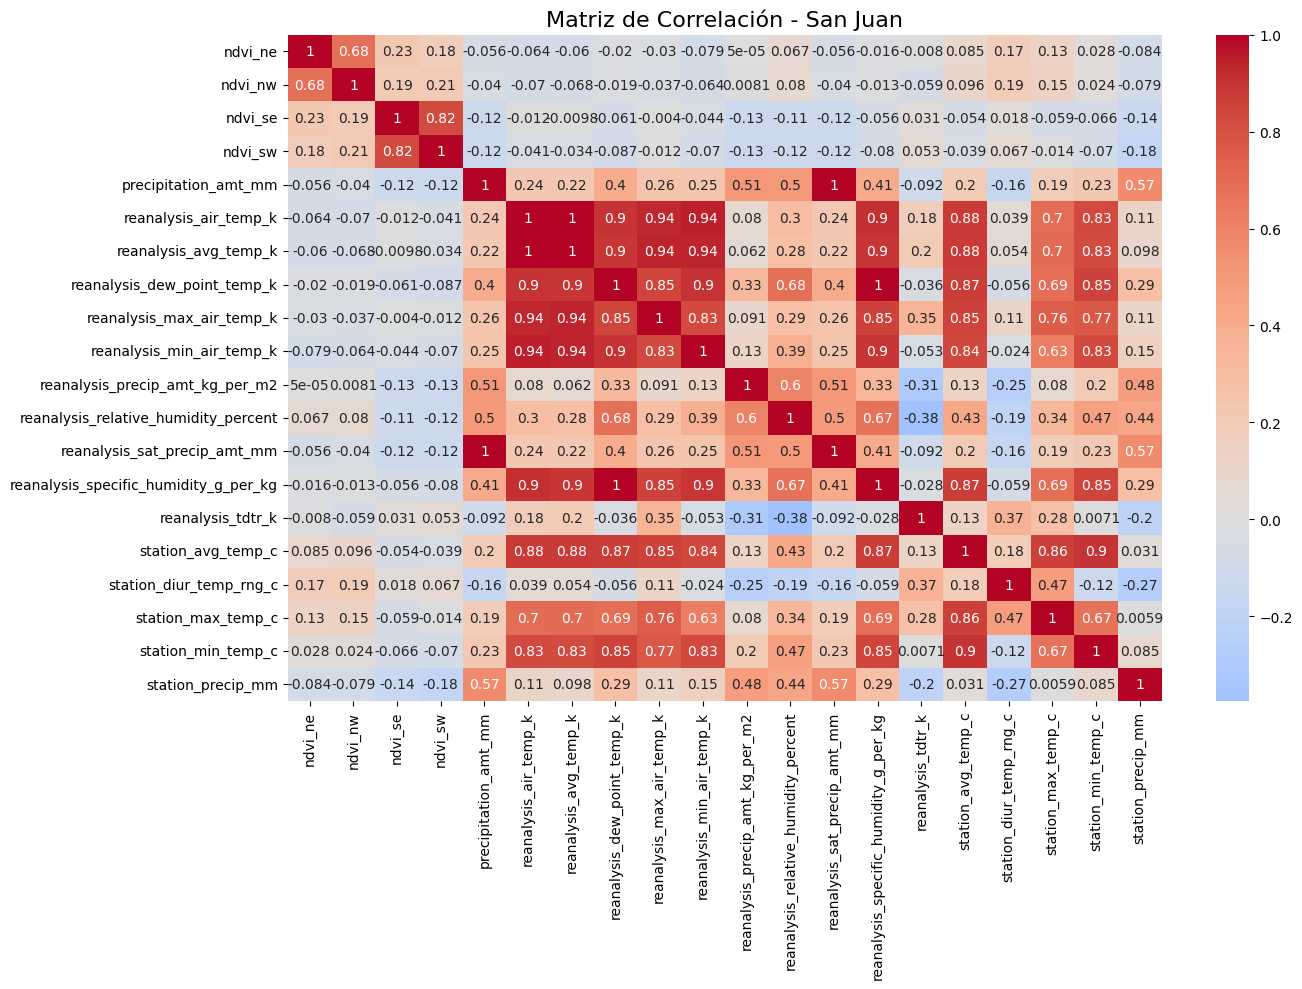

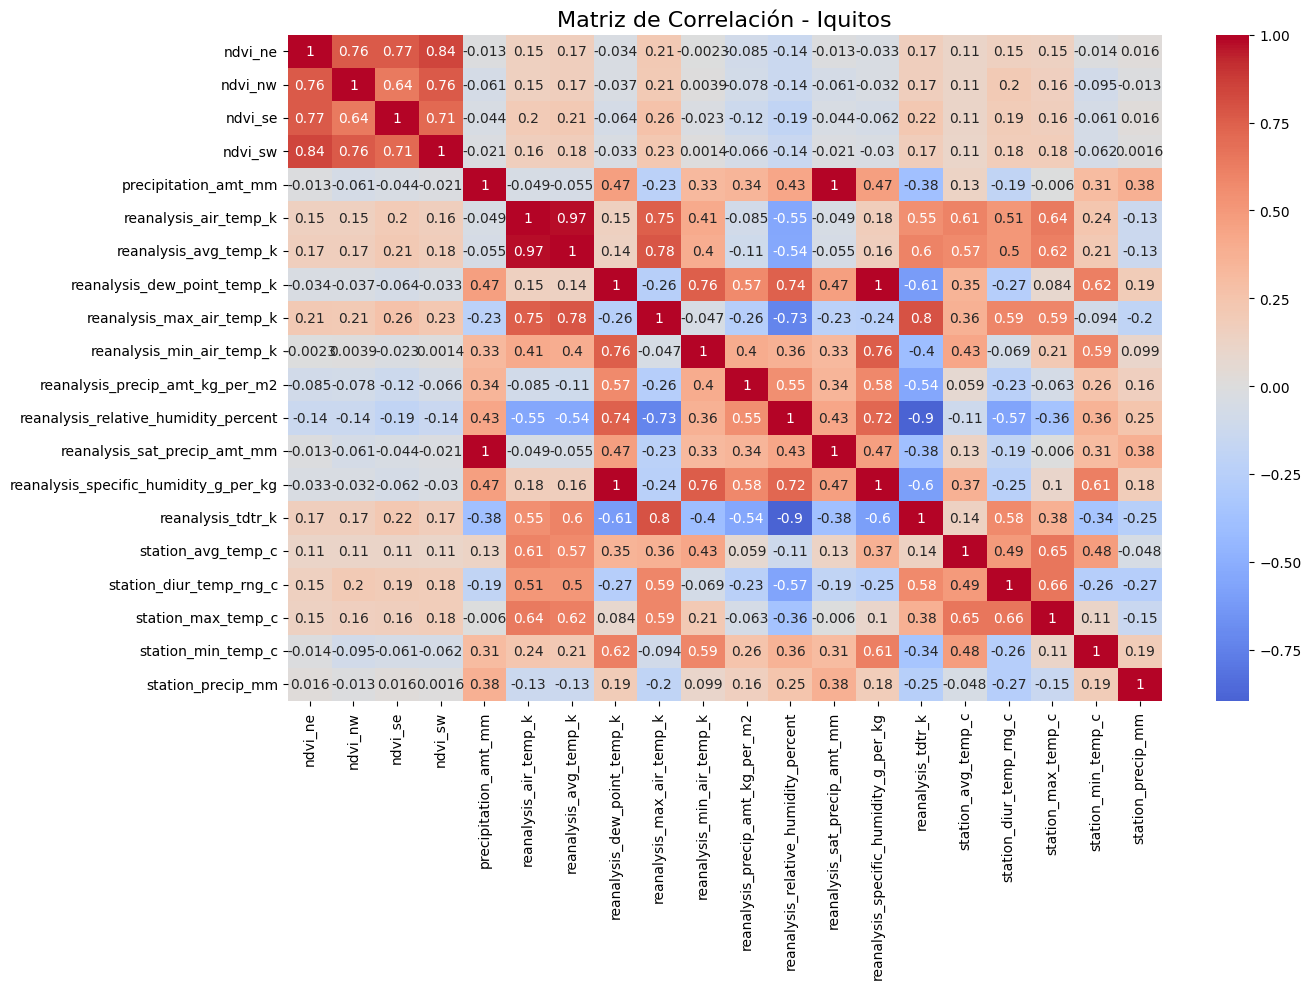

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Columnas a excluir (no numéricas / temporales)
cols_exclude = ['city', 'year', 'weekofyear', 'week_start_date']

# Correlación para San Juan
corr_sj = sj_imputed_df.drop(columns=cols_exclude).corr()

plt.figure(figsize=(14,10))
sns.heatmap(corr_sj, annot=True, cmap='coolwarm', center=0)
plt.title('Matriz de Correlación - San Juan', fontsize=16)
plt.tight_layout()
plt.show()

# Correlación para Iquitos
corr_iq = iq_imputed_df.drop(columns=cols_exclude).corr()

plt.figure(figsize=(14,10))
sns.heatmap(corr_iq, annot=True, cmap='coolwarm', center=0)
plt.title('Matriz de Correlación - Iquitos', fontsize=16)
plt.tight_layout()
plt.show()


### Conclusión del Análisis de Correlación (San Juan vs Iquitos)

El análisis de las matrices de correlación revela patrones comunes y diferencias entre ambas ciudades:

### Puntos en común
- **Alta correlación entre las variables de temperatura**:
  - `reanalysis_air_temp_k`, `reanalysis_avg_temp_k`, así como las temperaturas mínima y máxima de estación.
  - Indica **redundancia de información** y sugiere que un **PCA** puede condensar estos grupos de variables en menos componentes.
  
- **Relación entre precipitación y humedad**:
  - La precipitación acumulada (tanto satelital como de estación) tiende a correlacionarse con la humedad relativa y, en menor medida, con los índices de vegetación.

- **Correlaciones negativas con el rango térmico (`reanalysis_tdtr_k`)**:
  - A medida que aumenta la humedad y la nubosidad, la amplitud térmica diaria tiende a reducirse.

### Diferencias clave
- **San Juan**:
  - Presenta correlaciones más fuertes entre las **temperaturas de reanálisis y de estación** (bloques rojos muy definidos).
  - Los índices de vegetación **no están tan correlacionados entre sí** ni con las variables climáticas.

- **Iquitos**:
  - Los **índices NDVI** muestran correlaciones muy altas entre sí (>0.7), indicando que contienen información redundante.
  - La humedad específica tiene correlaciones moderadas con varias variables de temperatura y precipitación, reflejando la naturaleza húmeda y más variable del clima amazónico.

### Implicación para el análisis
- La existencia de **bloques de variables fuertemente correlacionadas** respalda el uso de **PCA** para:
  - Reducir la dimensionalidad.
  - Minimizar la redundancia.
  - Facilitar la interpretación de los patrones climáticos que influirán en los modelos posteriores, como el clustering.

 **Conclusión:**  
Ambos análisis confirman que el siguiente paso natural es aplicar **PCA** para extraer componentes principales que resuman la variabilidad esencial de los datos climáticos en cada ciudad.


## PCA (Análisis de Componentes Principales)

El análisis de correlación evidenció alta redundancia entre variables (especialmente temperaturas y NDVI).  
Para reducir la complejidad y evitar que variables correlacionadas influyan en exceso sobre el clustering, se aplica **PCA**.

### Metodología
- Se utilizan los **datasets imputados** de cada ciudad (`sj_imputed_df` e `iq_imputed_df`).
- Se eliminan las columnas no numéricas y se **escalan** las variables con `StandardScaler`.
- Se aplica **PCA**, reteniendo las componentes que explican al menos el **90% de la varianza acumulada**.
- El resultado son dos nuevos conjuntos reducidos (`sj_pcs` e `iq_pcs`) listos para los algoritmos de clustering.

El PCA permite trabajar con menos dimensiones manteniendo la mayor parte de la información climática relevante.


San Juan: 7 componentes explican 90.61% de la varianza.


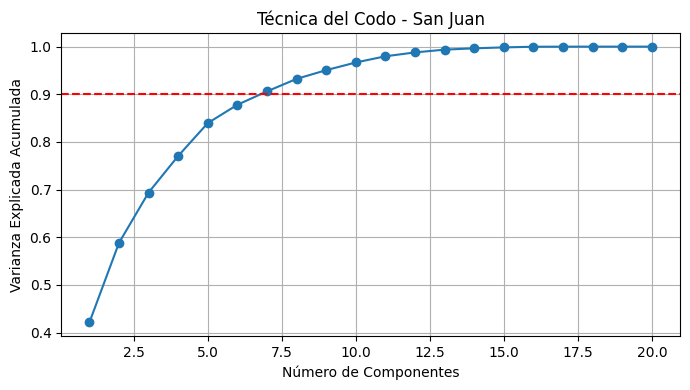

Iquitos: 8 componentes explican 91.30% de la varianza.


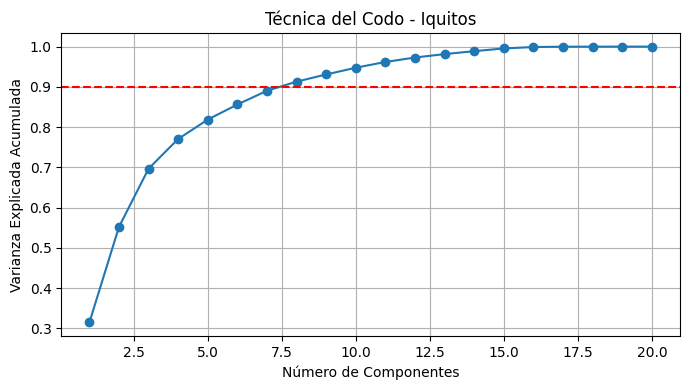

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

cols_exclude = ['city', 'year', 'weekofyear', 'week_start_date']

def aplicar_pca(df, nombre, varianza_obj=0.90, graficar=True):
    # Selección de variables numéricas
    X = df.drop(columns=cols_exclude)

    # Escalado
    X_scaled = StandardScaler().fit_transform(X)

    # PCA
    pca = PCA()
    X_pca = pca.fit_transform(X_scaled)

    # Varianza explicada acumulada
    var_acum = np.cumsum(pca.explained_variance_ratio_)
    k = int(np.argmax(var_acum >= varianza_obj) + 1)

    print(f"{nombre}: {k} componentes explican {var_acum[k-1]*100:.2f}% de la varianza.")

    # Gráfico de varianza explicada acumulada
    if graficar:
        plt.figure(figsize=(7,4))
        plt.plot(range(1, len(var_acum)+1), var_acum, marker='o')
        plt.axhline(y=varianza_obj, color='r', linestyle='--')
        plt.xlabel('Número de Componentes')
        plt.ylabel('Varianza Explicada Acumulada')
        plt.title(f'Técnica del Codo - {nombre}')
        plt.tight_layout()
        plt.grid(True)
        plt.show()

    # DataFrame con las componentes necesarias
    pcs_df = pd.DataFrame(X_pca[:, :k],
                          columns=[f'PC{i+1}' for i in range(k)],
                          index=df.index)

    return pcs_df

# Aplicar PCA
sj_pcs = aplicar_pca(sj_imputed_df, 'San Juan', varianza_obj=0.90)
iq_pcs = aplicar_pca(iq_imputed_df, 'Iquitos', varianza_obj=0.90)


### Conclusiones del PCA

El PCA permitió reducir de forma significativa la dimensionalidad de los datos, manteniendo la mayor parte de la información climática relevante.

### Varianza explicada
- En **San Juan**, el **90% de la varianza** se alcanza con **7 componentes principales**.  
- En **Iquitos**, se requieren **8 componentes** para alcanzar el mismo nivel de varianza explicada.
- Esto implica una reducción de más de 20 variables originales a un conjunto reducido que conserva la información esencial.

### Implicaciones
- La reducción de dimensionalidad **elimina redundancias** y mejora la eficiencia de los algoritmos de clustering.
- Los resultados justifican **mantener los análisis separados por ciudad**, ya que la estructura de variabilidad climática difiere entre San Juan e Iquitos.
- Los nuevos conjuntos (`sj_pcs` e `iq_pcs`) representan de forma compacta los factores climáticos más relevantes para el análisis posterior.

Con el PCA finalizado, los datos quedan listos para aplicar los distintos métodos de **clustering**.


---
# Clustering
---

Tras la reducción de dimensionalidad mediante **PCA**, el siguiente paso consiste en aplicar **técnicas de clustering** para identificar patrones climáticos en los datos de cada ciudad.

### Objetivo
- Agrupar semanas con **características climáticas similares**.
- Detectar posibles **patrones estacionales o climáticos** asociados a las condiciones favorables para la propagación del dengue.
- Evaluar distintos enfoques de clustering y comparar la estructura que cada uno revela.

### Metodología general
- Se emplean los datasets reducidos por PCA:
  - `sj_pcs` → San Juan  
  - `iq_pcs` → Iquitos
- Los análisis se realizan **por separado**, dada la diferencia en el comportamiento climático entre ambas ciudades.
- Cada algoritmo se aplica sobre las **componentes principales retenidas** (7 para San Juan, 8 para Iquitos).
- Se interpretan los resultados a través de visualizaciones y métricas de calidad del agrupamiento.

A continuación se presentan los cuatro métodos de clustering que se evaluarán:  
**Jerárquico, K-Means, DBSCAN y GMM**.


## Clustering Jerárquico

El **clustering jerárquico aglomerativo** agrupa los datos de forma progresiva, uniendo los puntos o grupos más similares según una medida de distancia, hasta formar una jerarquía de clusters.

### Objetivo
- Explorar la **estructura jerárquica de los datos climáticos**.
- Determinar un número adecuado de clusters a partir de los **dendrogramas**.
- Analizar los grupos resultantes como posibles patrones climáticos dominantes.

### Metodología
- Se utiliza la **distancia euclidiana** y el método de enlace **Ward**, que tiende a generar grupos compactos y homogéneos.
- Se construyen **dendrogramas** para ambas ciudades, a partir de sus datasets reducidos (`sj_pcs` e `iq_pcs`).
- El número de clusters se decide visualmente o según el salto máximo en las distancias de fusión.
- Finalmente, se aplica el modelo **AgglomerativeClustering** con el número de clusters elegido para obtener la asignación final de grupos.

Este método permite identificar de manera jerárquica la similitud entre semanas y descubrir **estructuras naturales de agrupamiento** en las variables climáticas reducidas por PCA.


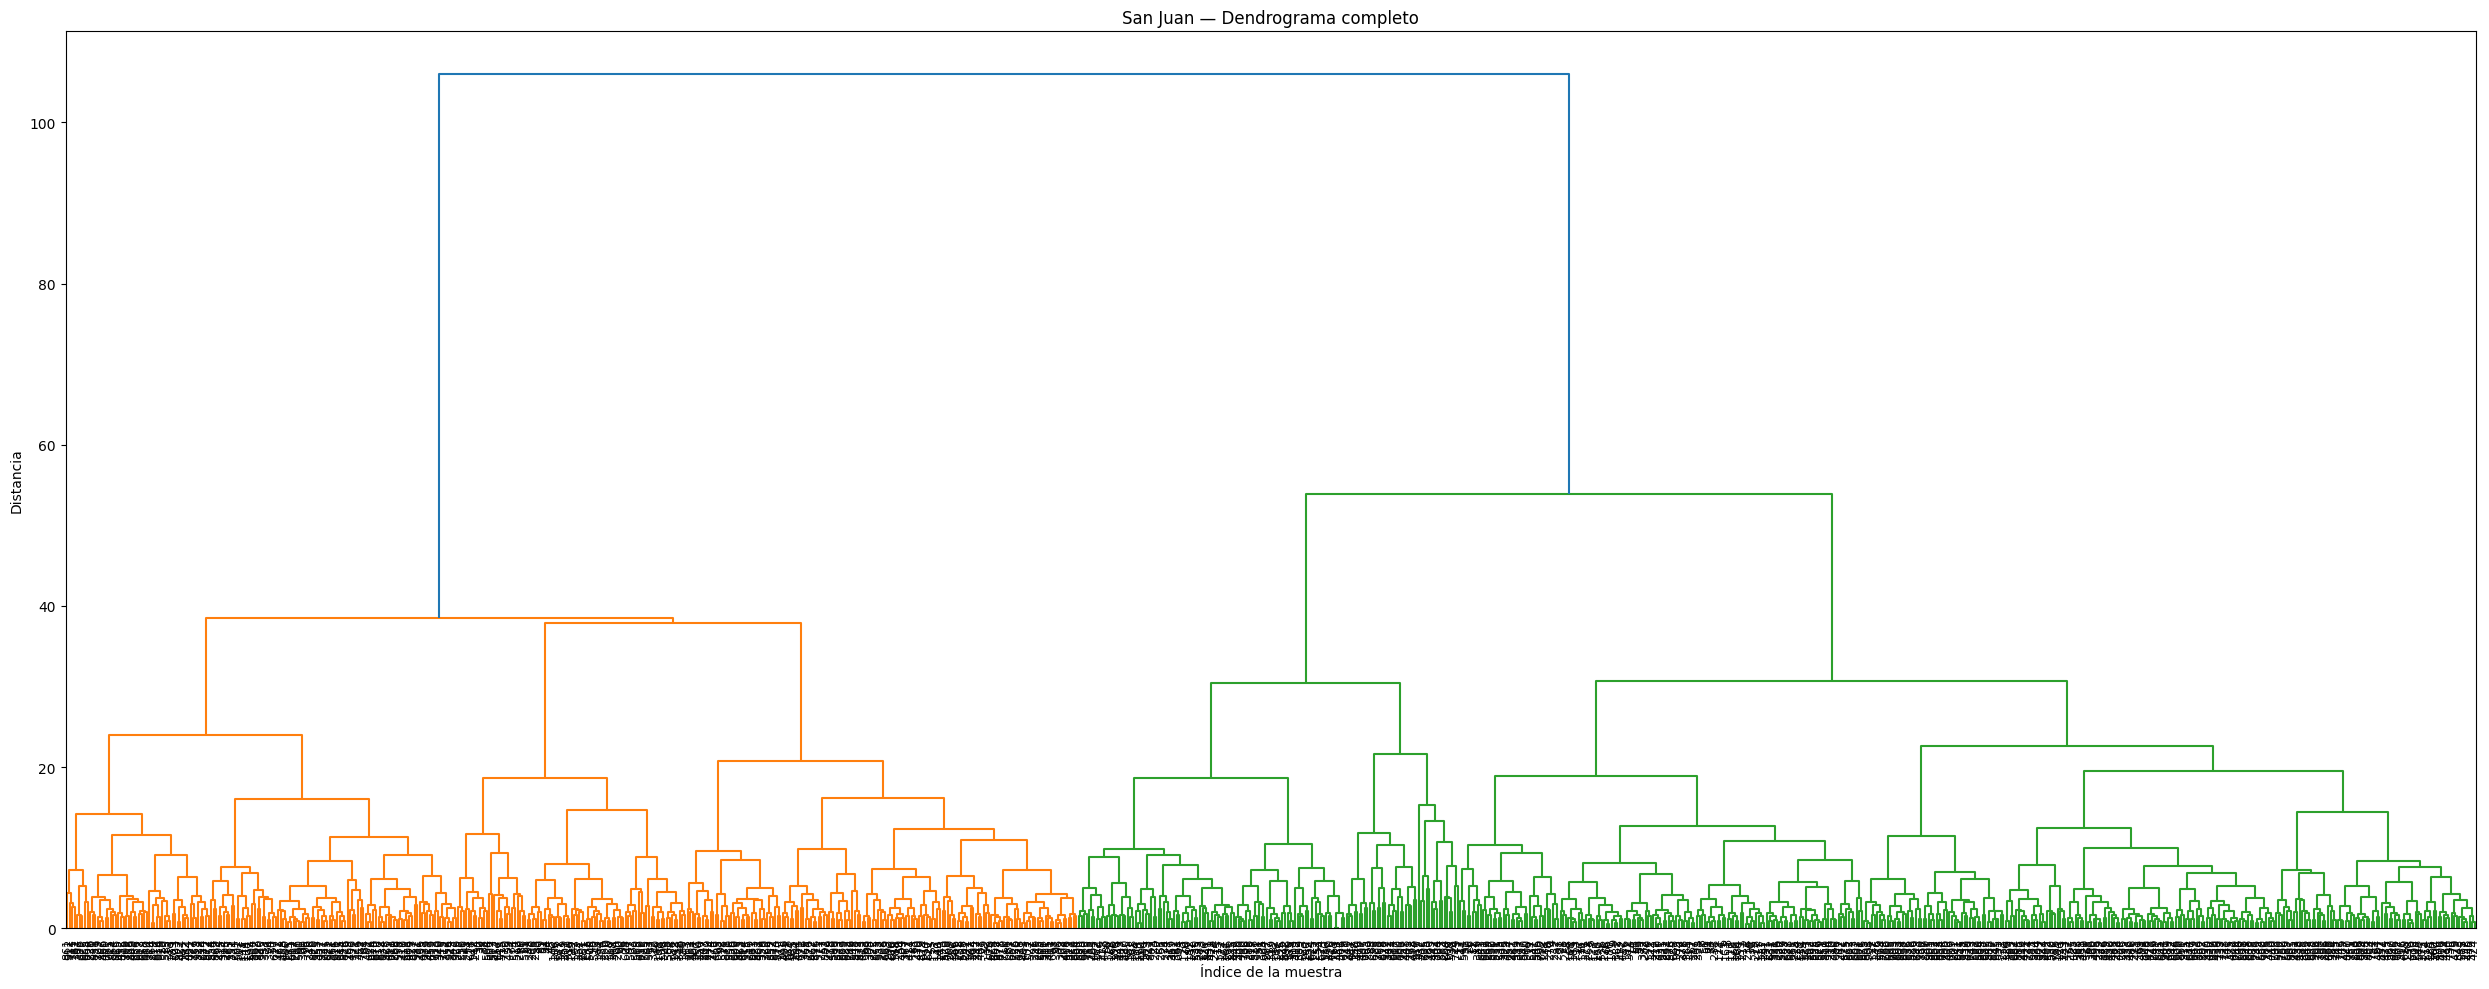

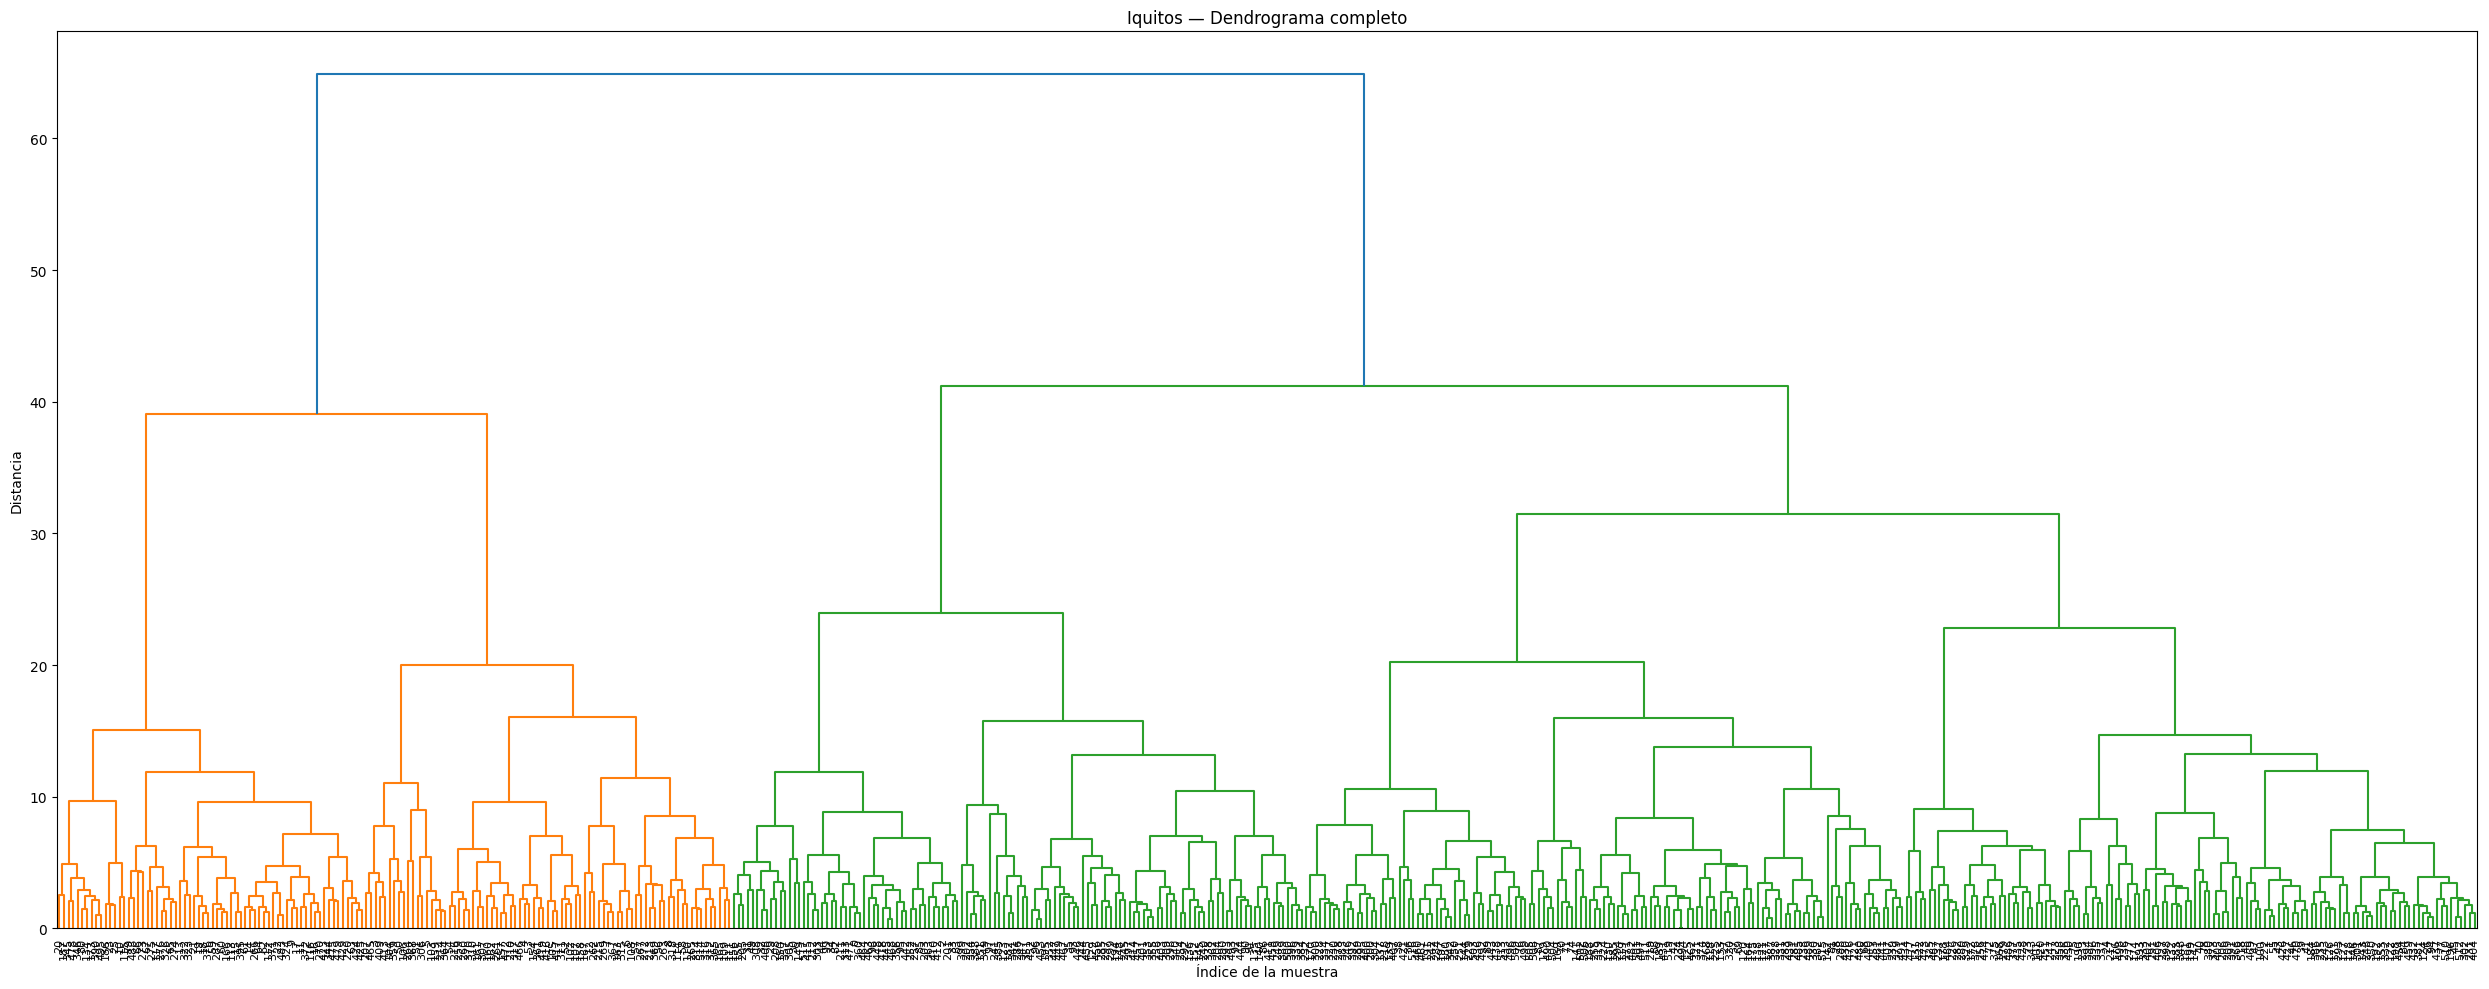

In [ ]:
from matplotlib import pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram

def dendrograma_completo(data, titulo='Dendrograma completo'):
    # Enlace jerárquico
    Z = linkage(data.values, method='ward')

    # Dendrograma completo
    plt.figure(figsize=(25, 10))
    plt.title(titulo)
    plt.xlabel('Índice de la muestra')
    plt.ylabel('Distancia')
    dendrogram(Z, leaf_rotation=90., leaf_font_size=8.)
    plt.tight_layout()
    plt.show()

    return Z

# Ejecutar por ciudad
Z_sj = dendrograma_completo(sj_pcs, titulo='San Juan — Dendrograma completo')
Z_iq = dendrograma_completo(iq_pcs, titulo='Iquitos — Dendrograma completo')


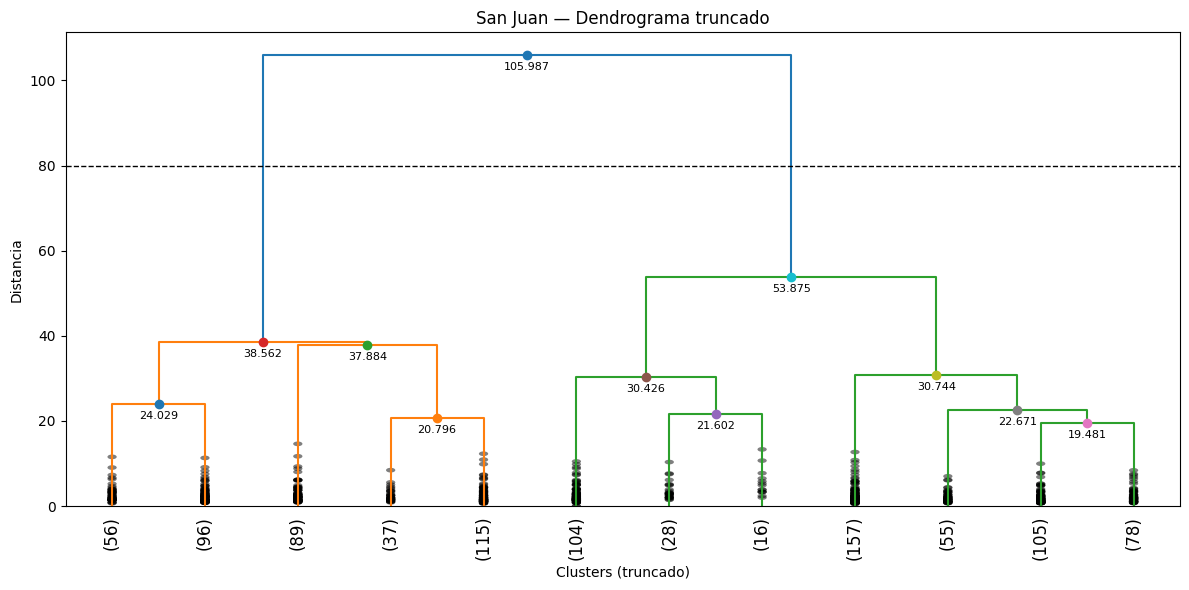

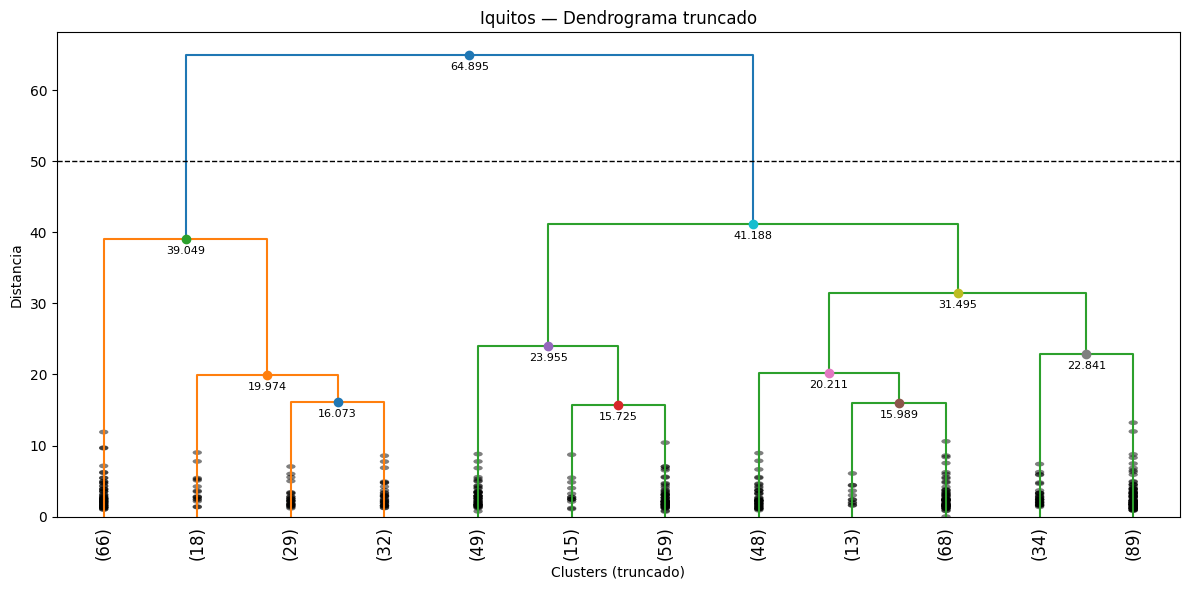

In [ ]:
from scipy.cluster.hierarchy import dendrogram

def fancy_dendrogram(*args, max_d=None, annotate_above=0, **kwargs):
    ddata = dendrogram(*args, **kwargs)
    if not kwargs.get('no_plot', False):
        import matplotlib.pyplot as plt
        for i, d, c in zip(ddata['icoord'], ddata['dcoord'], ddata['color_list']):
            x = 0.5 * sum(i[1:3])
            y = d[1]
            if y > annotate_above:
                plt.plot(x, y, 'o')
                plt.annotate(f'{y:.3f}', (x, y), xytext=(0, -5),
                             textcoords='offset points', va='top', ha='center', fontsize=8)
        if max_d is not None:
            plt.axhline(y=max_d, c='k', ls='--', lw=1)
    return ddata


def dendrograma_truncado(data, titulo='Dendrograma truncado', d_max=10, p_trunc=12):
    # Enlace
    Z = linkage(data.values, method='ward')

    # Dendrograma truncado
    plt.figure(figsize=(12, 6))
    fancy_dendrogram(
        Z,
        truncate_mode='lastp',
        p=p_trunc,
        leaf_rotation=90.,
        leaf_font_size=12.,
        show_contracted=True,
        annotate_above=1,
        max_d=d_max
    )
    plt.title(titulo)
    plt.xlabel('Clusters (truncado)')
    plt.ylabel('Distancia')
    plt.tight_layout()
    plt.show()

    return Z

# Ejecutar por ciudad
Z_sj_trunc = dendrograma_truncado(sj_pcs, titulo='San Juan — Dendrograma truncado', d_max=80, p_trunc=12)
Z_iq_trunc = dendrograma_truncado(iq_pcs, titulo='Iquitos — Dendrograma truncado', d_max=50, p_trunc=12)


In [ ]:
from sklearn.cluster import AgglomerativeClustering

# Matrices de entrada
X_sj = sj_pcs.values
X_iq = iq_pcs.values

# k elegidos desde los dendrogramas
k_sj = 2   # o 3 si decides la alternativa
k_iq = 2   # o 4 si decides la alternativa

# Clustering jerárquico
sj_model = AgglomerativeClustering(n_clusters=k_sj, linkage='ward')
iq_model = AgglomerativeClustering(n_clusters=k_iq, linkage='ward')

sj_labels = sj_model.fit_predict(X_sj)
iq_labels = iq_model.fit_predict(X_iq)

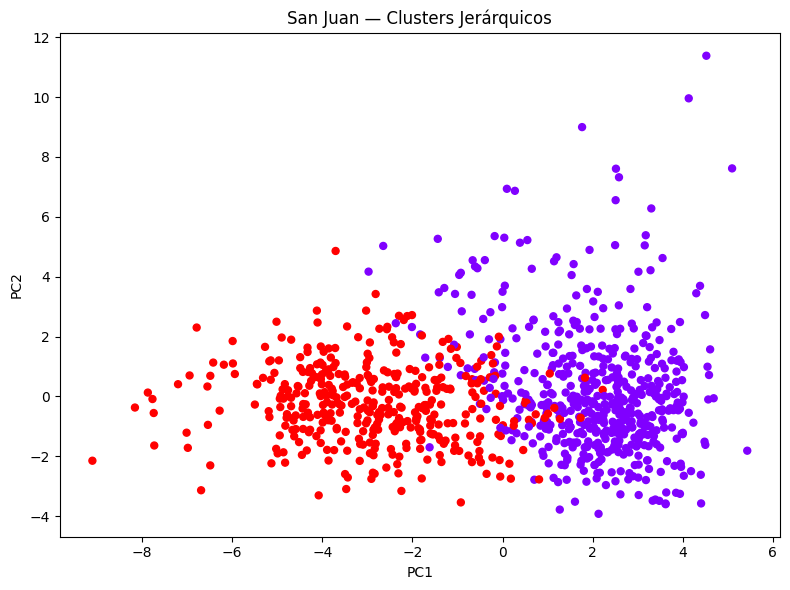

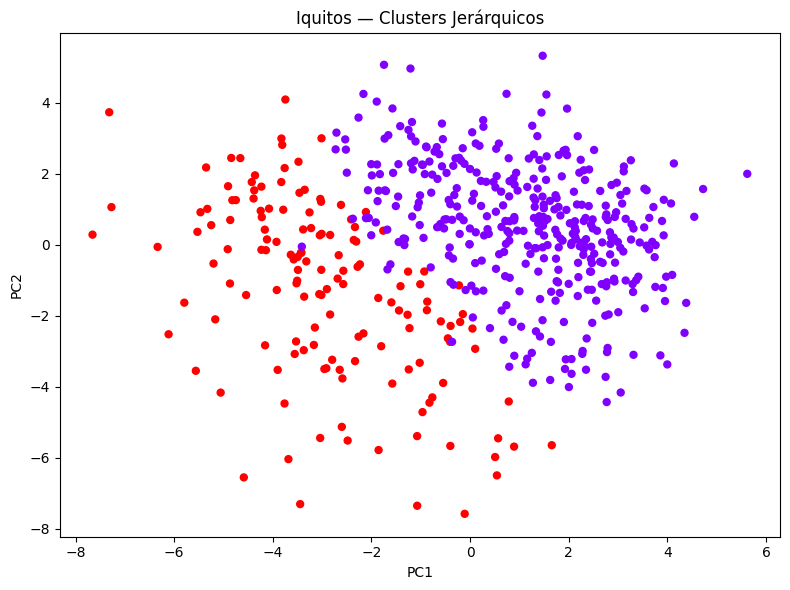

In [ ]:
import matplotlib.pyplot as plt

# San Juan
plt.figure(figsize=(8,6))
plt.scatter(
    sj_pcs.iloc[:, 0], sj_pcs.iloc[:, 1],
    c=sj_labels, cmap='rainbow', s=25
)
plt.title("San Juan — Clusters Jerárquicos")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

# Iquitos
plt.figure(figsize=(8,6))
plt.scatter(
    iq_pcs.iloc[:, 0], iq_pcs.iloc[:, 1],
    c=iq_labels, cmap='rainbow', s=25
)
plt.title("Iquitos — Clusters Jerárquicos")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()


### Conclusiones del Clustering Jerárquico

El análisis jerárquico permitió identificar la estructura de agrupamiento en ambas ciudades:

- **San Juan:** se observa un salto claro cerca de la distancia 80, indicando **2 clústeres principales**, aunque una división en **3** también sería razonable por la variabilidad interna.  
- **Iquitos:** el corte más evidente aparece en torno a la distancia 50, con posibilidad de subdividir hasta en **4 clústeres**, reflejando una mayor diversidad climática.

En conjunto, **San Juan** presenta una estructura más compacta, mientras que **Iquitos** muestra patrones más fragmentados, lo que sugiere dinámicas climáticas más complejas.


## K-Means

**Objetivo.** Agrupar semanas con características climáticas similares en el espacio reducido por PCA.

**Metodología.**
- Se aplica **K-Means** sobre `sj_pcs` e `iq_pcs` (componentes principales retenidas).
- Se prueban los valores de **k** sugeridos por los dendrogramas (SJ: 2–3; IQ: 2–4) y se comparan métricas:
  - **Silhouette** (↑ mejor), **Calinski–Harabasz** (↑ mejor), **Davies–Bouldin** (↓ mejor).
- Se elige el **k** con mejor compromiso y se reporta la partición final.


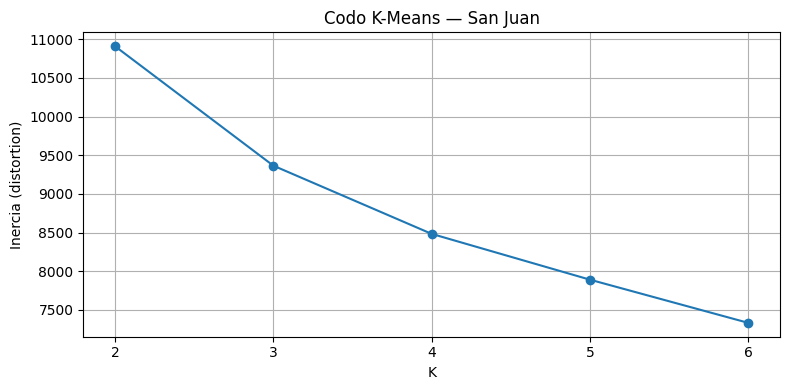

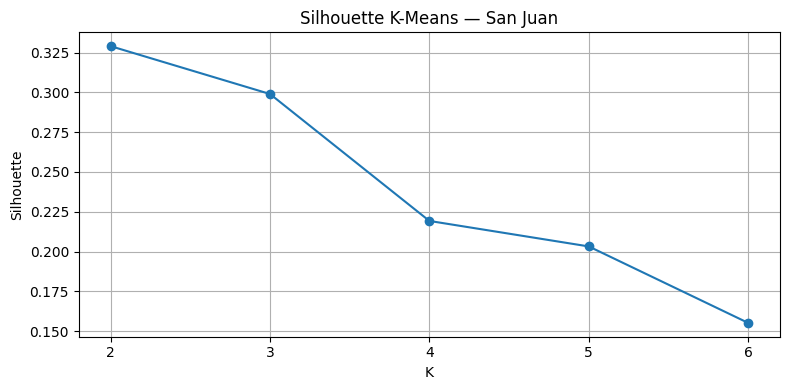

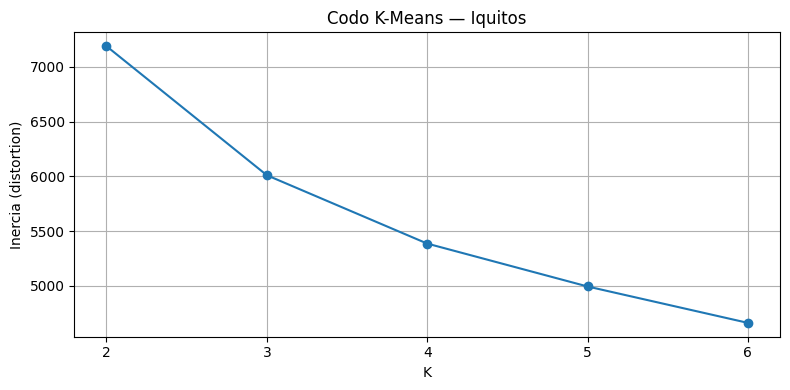

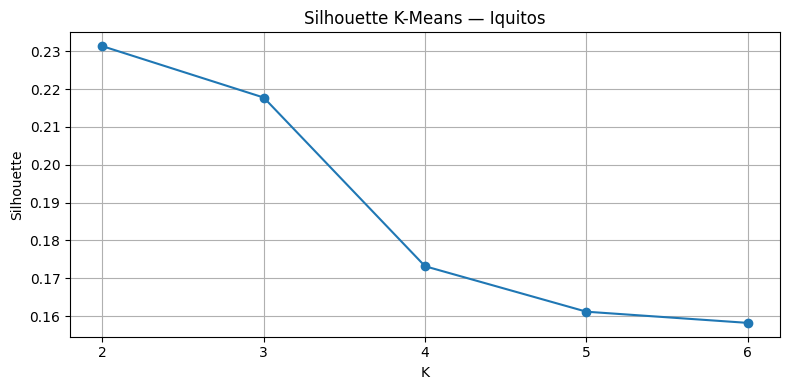

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn import metrics

plt.rcParams['figure.figsize'] = [8, 4]

def evaluar_kmeans(X, k_min=2, k_max=10, titulo=""):
    ks = list(range(k_min, k_max+1))
    distortions, silhouettes = [], []

    for k in ks:
        km = KMeans(
            n_clusters=k,
            init='random',
            n_init=10,
            max_iter=300,
            tol=1e-4,
            random_state=42
        )
        labels = km.fit_predict(X)
        distortions.append(km.inertia_)
        silhouettes.append(metrics.silhouette_score(X, labels))

    # Plot Codo
    plt.figure()
    plt.plot(ks, distortions, marker='o')
    plt.xticks(ks)
    plt.xlabel('K')
    plt.ylabel('Inercia (distortion)')
    plt.title(f'Codo K-Means — {titulo}')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Plot Silhouette
    plt.figure()
    plt.plot(ks, silhouettes, marker='o')
    plt.xticks(ks)
    plt.xlabel('K')
    plt.ylabel('Silhouette')
    plt.title(f'Silhouette K-Means — {titulo}')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return pd.DataFrame({
        'k': ks,
        'inertia': distortions,
        'silhouette': silhouettes
    })

# Datos
X_sj = sj_pcs.values
X_iq = iq_pcs.values

res_sj = evaluar_kmeans(X_sj, k_min=2, k_max=6,  titulo="San Juan")
res_iq = evaluar_kmeans(X_iq, k_min=2, k_max=6,  titulo="Iquitos")

### Conclusiones — K-Means

El análisis mediante los métodos del **codo** y del **índice de Silhouette** permitió determinar un número adecuado de clusters para cada ciudad.

### San Juan
- El **método del codo** presenta una inflexión clara en **K = 3**, donde la reducción de inercia comienza a estabilizarse.  
- Aunque el valor de **Silhouette** es ligeramente mayor en **K = 2**, la diferencia es pequeña, y **K = 3** permite una mejor diferenciación de los patrones climáticos.  
- Se considera que **tres clusters** representan adecuadamente la diversidad de condiciones climáticas en la ciudad.

### Iquitos
- Tanto el **codo** como el **Silhouette** indican que el cambio más significativo ocurre entre **K = 2 y K = 3**, estabilizándose después.  
- Pese a la ligera caída del Silhouette en **K = 3**, esta opción ofrece una segmentación más rica y coherente con la variabilidad climática observada.  
- Por tanto, también se opta por **K = 3** como número óptimo de clusters.


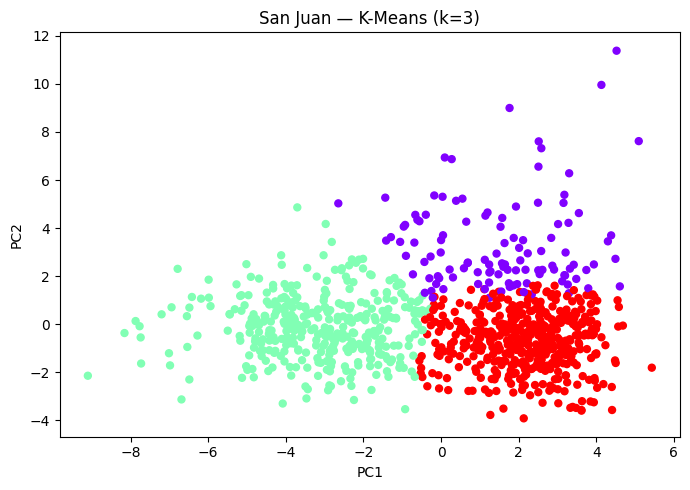

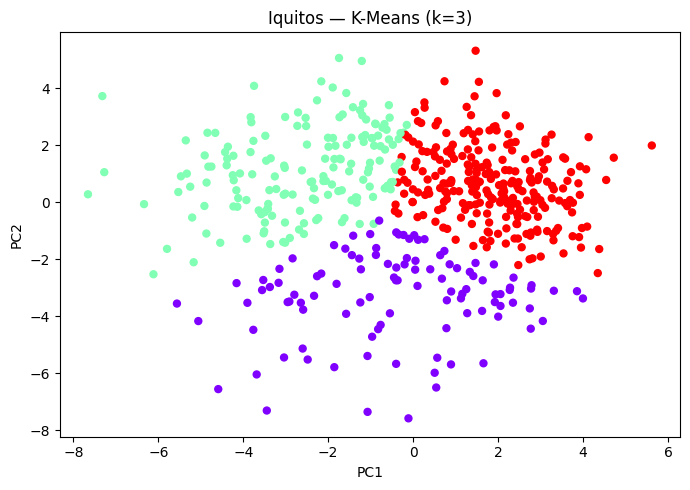

In [ ]:
# K elegidos
k_sj = 3  # según codo/silhouette o dendrogramas
k_iq = 3  # según codo/silhouette o dendrogramas

km_sj = KMeans(n_clusters=k_sj, init='random', n_init=10, max_iter=300, tol=1e-4, random_state=42)
km_iq = KMeans(n_clusters=k_iq, init='random', n_init=10, max_iter=300, tol=1e-4, random_state=42)

sj_km_labels = km_sj.fit_predict(X_sj)
iq_km_labels = km_iq.fit_predict(X_iq)

# Visualización de apoyo
plt.figure(figsize=(7,5))
plt.scatter(X_sj[:,0], X_sj[:,1], c=sj_km_labels, cmap='rainbow', s=25)
plt.title(f"San Juan — K-Means (k={k_sj})"); plt.xlabel("PC1"); plt.ylabel("PC2")
plt.tight_layout(); plt.show()

plt.figure(figsize=(7,5))
plt.scatter(X_iq[:,0], X_iq[:,1], c=iq_km_labels, cmap='rainbow', s=25)
plt.title(f"Iquitos — K-Means (k={k_iq})"); plt.xlabel("PC1"); plt.ylabel("PC2")
plt.tight_layout(); plt.show()


### Conclusiones Visuales — K-Means (K=3)

Los resultados del algoritmo K-Means con **tres clusters** muestran una clara segmentación de las condiciones climáticas en ambas ciudades:

- **San Juan:** los grupos se distribuyen principalmente a lo largo del primer componente (PC1), lo que indica que las diferencias entre clusters se asocian sobre todo con **gradientes térmicos o de humedad**. Se distinguen tres zonas bien definidas, lo que sugiere **tres regímenes climáticos principales**.

- **Iquitos:** la separación de los grupos es más uniforme en ambos componentes (PC1 y PC2), lo que refleja una **variabilidad más equilibrada entre temperatura, precipitación y vegetación**. Los tres clusters representan distintos estados climáticos, posiblemente vinculados con **épocas del año o niveles de precipitación**.



---
## DBSCAN (Clustering basado en densidad)
---

El algoritmo **DBSCAN (Density-Based Spatial Clustering of Applications with Noise)** agrupa puntos según su densidad en el espacio.  
A diferencia de K-Means, **no requiere especificar el número de clusters** y puede detectar grupos de **formas arbitrarias**, identificando además puntos **ruidosos o aislados**.

### Objetivo
- Detectar regiones densas en los datos climáticos proyectados mediante PCA.  
- Identificar puntos atípicos o de baja densidad que no pertenecen a ningún grupo.  

### Metodología
1. Se emplean los datos **ya transformados por PCA** y **escalados previamente**.  
2. Se utiliza el **gráfico de distancias al *k*-ésimo vecino** (*k-dist plot*) para estimar un valor adecuado del parámetro `eps`.  
3. El parámetro `min_samples` se fija como **número de dimensiones + 1**, siguiendo la práctica común.  
4. Una vez seleccionados los parámetros, se ajusta **DBSCAN** por separado en cada ciudad (San Juan e Iquitos) y se visualizan los resultados en el plano **PC1–PC2**.


San Juan → min_samples = 8
Iquitos  → min_samples = 9


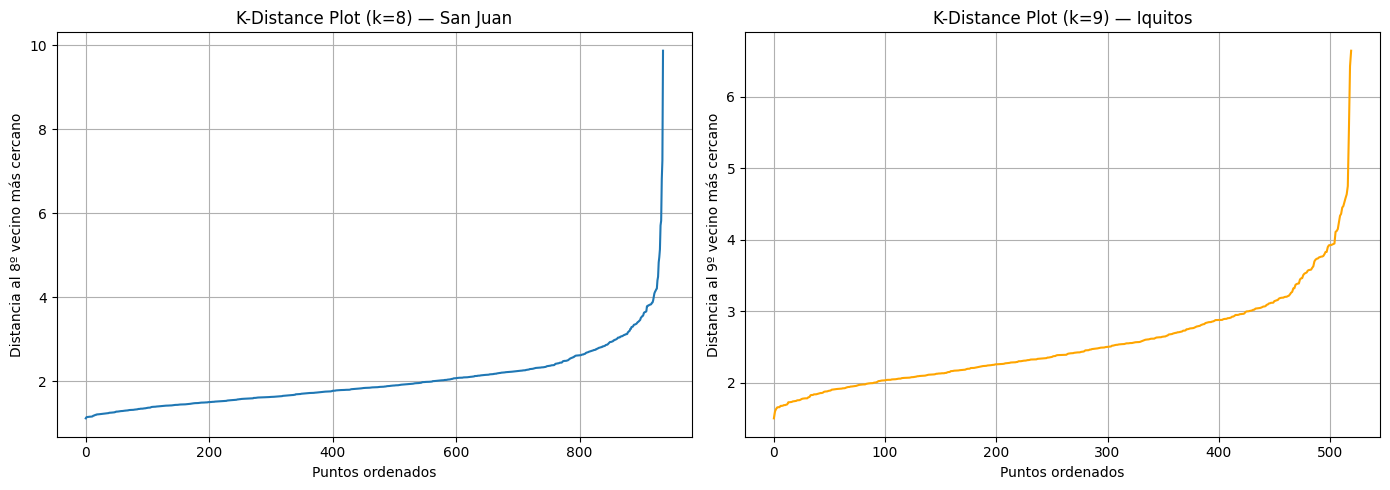

In [ ]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

# min_samples = n_dimensiones + 1
k_sj = sj_pcs.shape[1] + 1
k_iq = iq_pcs.shape[1] + 1

print(f"San Juan → min_samples = {k_sj}")
print(f"Iquitos  → min_samples = {k_iq}")

# Calcular distancias San Juan
neigh_sj = NearestNeighbors(n_neighbors=k_sj)
neigh_sj.fit(sj_pcs.values)
distances_sj, _ = neigh_sj.kneighbors(sj_pcs.values)
distances_sj = np.sort(distances_sj[:, k_sj - 1])

# Calcular distancias Iquitos
neigh_iq = NearestNeighbors(n_neighbors=k_iq)
neigh_iq.fit(iq_pcs.values)
distances_iq, _ = neigh_iq.kneighbors(iq_pcs.values)
distances_iq = np.sort(distances_iq[:, k_iq - 1])

# Gráficos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(distances_sj)
axes[0].set_title(f'K-Distance Plot (k={k_sj}) — San Juan')
axes[0].set_xlabel('Puntos ordenados')
axes[0].set_ylabel(f'Distancia al {k_sj}º vecino más cercano')
axes[0].grid(True)

axes[1].plot(distances_iq, color='orange')
axes[1].set_title(f'K-Distance Plot (k={k_iq}) — Iquitos')
axes[1].set_xlabel('Puntos ordenados')
axes[1].set_ylabel(f'Distancia al {k_iq}º vecino más cercano')
axes[1].grid(True)

plt.tight_layout()
plt.show()


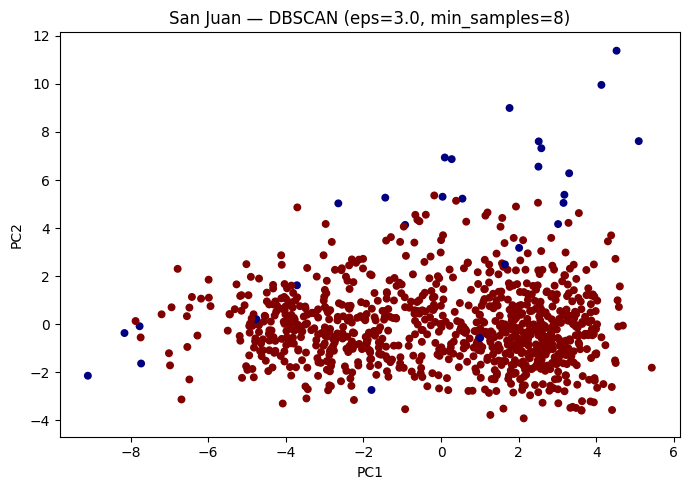

In [ ]:
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

X_sj = sj_pcs.values
eps_sj = 3.0
min_samples_sj = X_sj.shape[1] + 1

dbscan_sj = DBSCAN(eps=eps_sj, min_samples=min_samples_sj)
clusters_sj = dbscan_sj.fit_predict(X_sj)

plt.figure(figsize=(7,5))
plt.scatter(X_sj[:, 0], X_sj[:, 1], c=clusters_sj, cmap='jet', s=22)
plt.title(f"San Juan — DBSCAN (eps={eps_sj}, min_samples={min_samples_sj})")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.tight_layout(); plt.show()



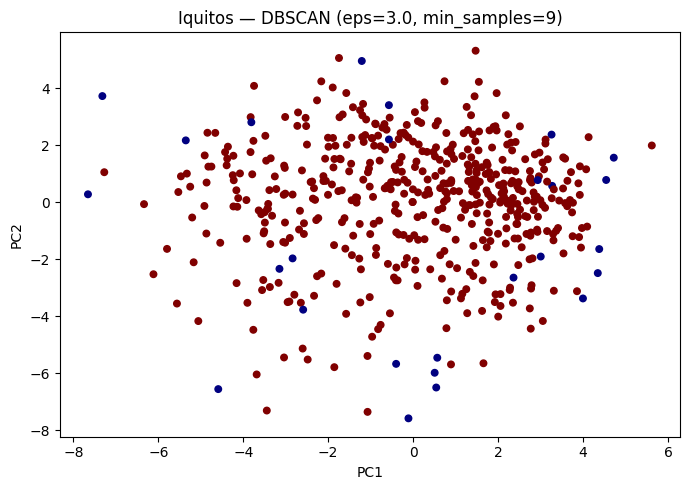

In [ ]:
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

X_iq = iq_pcs.values
eps_iq = 3.0
min_samples_iq = X_iq.shape[1] + 1

dbscan_iq = DBSCAN(eps=eps_iq, min_samples=min_samples_iq)
clusters_iq = dbscan_iq.fit_predict(X_iq)

plt.figure(figsize=(7,5))
plt.scatter(X_iq[:, 0], X_iq[:, 1], c=clusters_iq, cmap='jet', s=22)
plt.title(f"Iquitos — DBSCAN (eps={eps_iq}, min_samples={min_samples_iq})")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.tight_layout(); plt.show()


### Conclusiones del método DBSCAN

El análisis mediante **DBSCAN** permitió explorar la estructura de densidad en los datos climáticos reducidos por PCA.

- En **San Juan**, con `eps=3.0` y `min_samples=8`, el algoritmo identificó un único grupo principal y algunos puntos dispersos clasificados como **ruido**. Esto sugiere que las condiciones climáticas son relativamente homogéneas, con pocas observaciones fuera de los patrones dominantes.  
- En **Iquitos**, con `eps=3.0` y `min_samples=9`, se observa un comportamiento similar: la mayoría de los puntos se agrupan en una sola región densa, con un pequeño número de **outliers** aislados.  
- Los **gráficos de distancia k-ésimo vecino** mostraron un cambio de pendiente claro alrededor de las distancias seleccionadas para `eps`, validando la elección de los parámetros.

En conjunto, los resultados indican que los datos no presentan múltiples regiones de alta densidad claramente diferenciadas, sino un patrón climático más continuo, con algunos valores atípicos detectados como ruido por DBSCAN.


---
## Modelos Probabilísticos (GMM)
---

El método de **Mezclas de Gaussianas (GMM, *Gaussian Mixture Model*)** asume que los datos provienen de una combinación de varias distribuciones normales.  
A diferencia de K-Means, **GMM no asigna cada punto a un único cluster de forma rígida**, sino que calcula la **probabilidad** de pertenencia a cada grupo.

### Objetivo
- Identificar grupos naturales en los datos basados en la probabilidad de pertenencia.  
- Analizar la estructura subyacente de los patrones climáticos con un modelo más flexible que K-Means.  

### Metodología
1. Se utilizan las **componentes principales** obtenidas por PCA como entrada.  
2. Se prueba con distintos números de componentes (clusters) y se evalúan los criterios de información:
   - **AIC** (*Akaike Information Criterion*).
   - **BIC** (*Bayesian Information Criterion*).
3. El número óptimo de clusters se elige minimizando AIC y BIC.  
4. Finalmente, se visualizan los resultados de GMM para cada ciudad en el plano **PC1–PC2**, mostrando las regiones de mayor probabilidad de pertenencia a cada cluster.


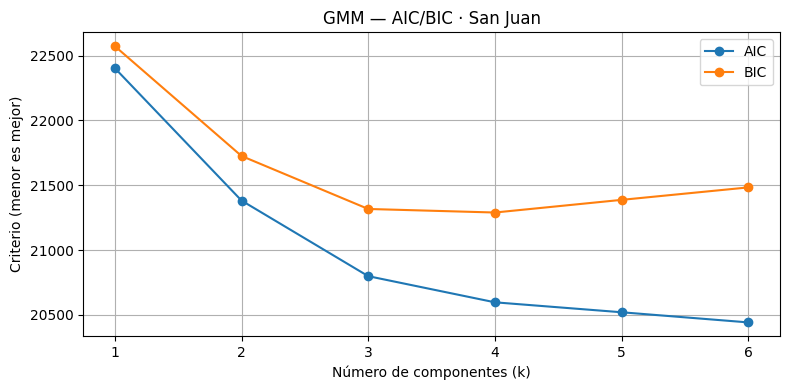

San Juan → k*_AIC = 6, k*_BIC = 4


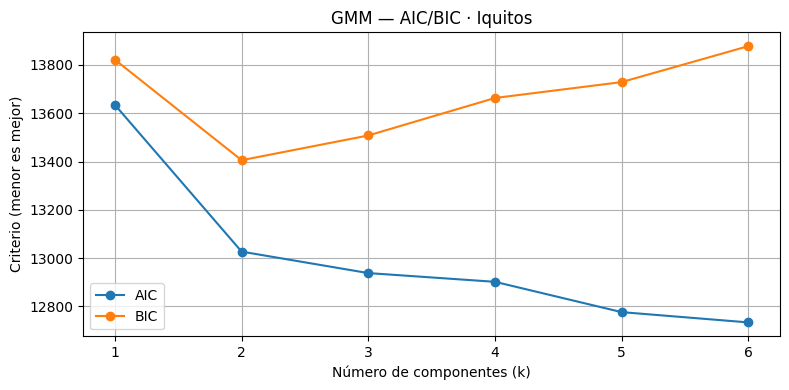

Iquitos → k*_AIC = 6, k*_BIC = 2


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture

def evaluar_gmm(X, ks=range(1, 7), cov_type="full", titulo=""):
    aic, bic = [], []
    for k in ks:
        gmm = GaussianMixture(n_components=k, covariance_type=cov_type, n_init=10, random_state=42)
        gmm.fit(X)
        aic.append(gmm.aic(X))
        bic.append(gmm.bic(X))

    # Graficar
    plt.figure(figsize=(8,4))
    plt.plot(ks, aic, marker='o', label='AIC')
    plt.plot(ks, bic, marker='o', label='BIC')
    plt.xticks(list(ks))
    plt.xlabel("Número de componentes (k)")
    plt.ylabel("Criterio (menor es mejor)")
    plt.title(f"GMM — AIC/BIC · {titulo}")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    k_aic = ks[int(np.argmin(aic))]
    k_bic = ks[int(np.argmin(bic))]
    print(f"{titulo} → k*_AIC = {k_aic}, k*_BIC = {k_bic}")
    return {"ks": list(ks), "aic": aic, "bic": bic, "k_aic": k_aic, "k_bic": k_bic}

# Datos
X_sj = sj_pcs.values
X_iq = iq_pcs.values

res_sj = evaluar_gmm(X_sj, ks=range(1,7), cov_type="full", titulo="San Juan")
res_iq = evaluar_gmm(X_iq, ks=range(1,7), cov_type="full", titulo="Iquitos")


In [ ]:
from sklearn.mixture import GaussianMixture
import numpy as np

k_sj = res_sj["k_bic"]
k_iq = res_iq["k_bic"]

gmm_sj = GaussianMixture(n_components=k_sj, covariance_type="full", n_init=10, random_state=42).fit(X_sj)
gmm_iq = GaussianMixture(n_components=k_iq, covariance_type="full", n_init=10, random_state=42).fit(X_iq)

# Etiquetas "duras" (cluster más probable)
sj_gmm_labels = gmm_sj.predict(X_sj)
iq_gmm_labels = gmm_iq.predict(X_iq)

# Probabilidades (responsabilidades)
sj_proba = gmm_sj.predict_proba(X_sj)
iq_proba = gmm_iq.predict_proba(X_iq)

print(f"San Juan → k={k_sj}")
print(f"Iquitos  → k={k_iq}")


San Juan → k=4
Iquitos  → k=2


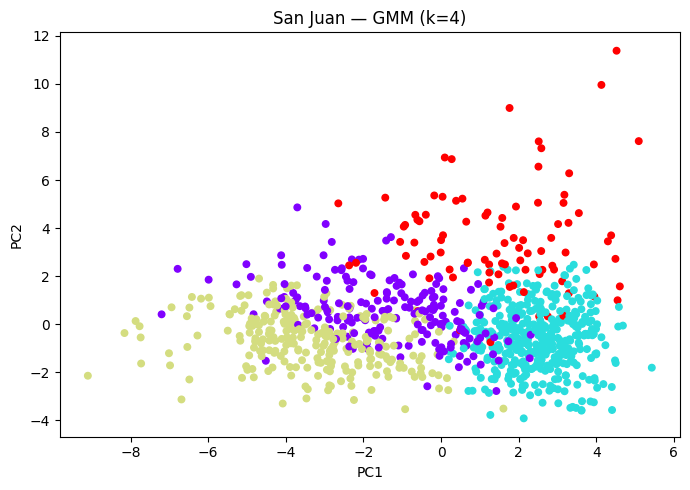

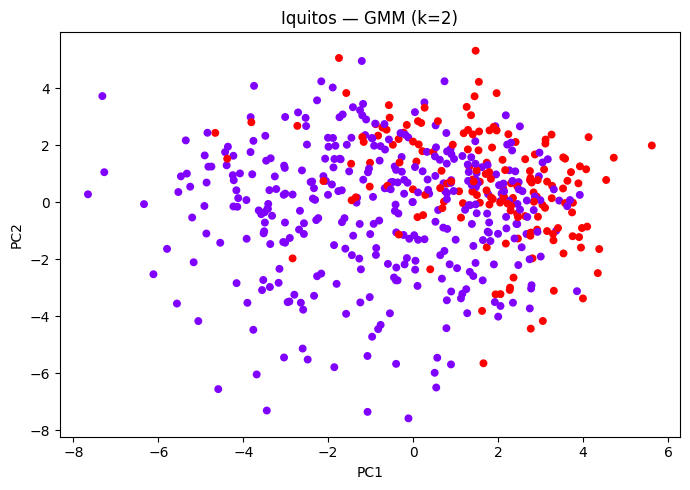

In [ ]:
import matplotlib.pyplot as plt

# San Juan
plt.figure(figsize=(7,5))
plt.scatter(X_sj[:,0], X_sj[:,1], c=sj_gmm_labels, s=22, cmap='rainbow')
plt.title(f"San Juan — GMM (k={k_sj})")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.tight_layout(); plt.show()

# Iquitos
plt.figure(figsize=(7,5))
plt.scatter(X_iq[:,0], X_iq[:,1], c=iq_gmm_labels, s=22, cmap='rainbow')
plt.title(f"Iquitos — GMM (k={k_iq})")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.tight_layout(); plt.show()


### Conclusiones del modelo GMM

El análisis con **Modelos de Mezcla de Gaussianas (GMM)** permitió identificar estructuras probabilísticas más flexibles en los datos climáticos.

- En **San Juan**, los criterios de información (AIC y BIC) indicaron un número óptimo de **4 componentes**, lo que sugiere una mayor complejidad en los patrones climáticos.  
  Los clusters muestran cierta superposición entre regiones, coherente con la naturaleza probabilística del modelo.

- En **Iquitos**, tanto el AIC como el BIC señalaron que el mejor ajuste se alcanza con **2 componentes**, reflejando una estructura más simple y homogénea respecto a San Juan.

- En ambos casos, GMM ofrece una descripción más suave de los límites entre grupos, permitiendo representar transiciones graduales entre distintos regímenes climáticos.

En conjunto, los resultados de GMM confirman la presencia de varios patrones de variabilidad climática, con **San Juan presentando una estructura más diversa** y **Iquitos mostrando una distribución más uniforme**, en línea con los hallazgos previos de K-Means y Jerárquico.


---
# Conclusiones
---

### Discusión de resultados

El análisis de clustering aplicado a los datos climáticos de **San Juan** e **Iquitos** permitió identificar patrones consistentes en la variabilidad semanal de las condiciones meteorológicas.  
La reducción de dimensionalidad mediante **PCA** (manteniendo el 90% de la varianza con 7–8 componentes) fue clave para eliminar redundancia entre variables y mejorar la estabilidad de los algoritmos de agrupamiento.

Entre los métodos evaluados:
- El **clustering jerárquico (Ward)** ofreció una visión clara de la estructura global de los datos y sirvió para estimar un número inicial de grupos razonable.  
- El **K-Means**, tras analizar los criterios del **codo** y **silhouette**, resultó ser el método **más robusto y equilibrado**, especialmente con **k=3**, separando con claridad distintos regímenes climáticos en ambas ciudades.  
- El **DBSCAN** no logró detectar una estructura de densidad significativa, lo que sugiere que los datos climáticos, tras el PCA, no presentan zonas bien diferenciadas de alta densidad.  
- El **GMM** proporcionó una segmentación más flexible: **San Juan** mostró cuatro subgrupos con transiciones suaves entre ellos, mientras que **Iquitos** se describió bien con solo dos componentes, reflejando su mayor homogeneidad climática.

En conjunto, los resultados indican que **K-Means y GMM** son los algoritmos **más prometedores**, ya que logran una partición coherente y estable, capturando tanto grupos definidos como transiciones graduales en los patrones climáticos.

---

### Reutilización en un modelo supervisado

En una futura actividad orientada a **predicción del número de contagios**, podrían reutilizarse los siguientes elementos del flujo de trabajo:

- **Preprocesado de datos**: imputación de valores faltantes y escalado estandarizado de variables.  
- **Selección de variables** y **PCA**, que reduce el ruido y evita la multicolinealidad, resultando en un conjunto compacto y eficiente de predictores.  
- Los **clusters obtenidos** (por K-Means o GMM) podrían integrarse como **variable categórica** adicional, representando distintos "regímenes climáticos" semanales.

En cambio, los modelos de clustering en sí mismos no serían reutilizados directamente, ya que la predicción de contagios requiere un enfoque **supervisado** basado en correlaciones explícitas entre clima y casos reportados.

---

### Trabajo futuro

Algunas líneas de mejora y ampliación del estudio serían:

- **Optimización automática de hiperparámetros** (por ejemplo, `k`, `eps`, `min_samples`) mediante búsqueda sistemática o validación cruzada no supervisada.  
- **Análisis temporal** incorporando el orden cronológico de las semanas, para capturar dinámicas estacionales y no solo relaciones estáticas.  
- **Integración de variables epidemiológicas** (como incidencias de dengue) en modelos mixtos clima–salud para explorar causalidad o predicción temprana.  
- Evaluar la **estabilidad de los clusters** en distintos periodos de tiempo y entre ciudades, verificando la persistencia de los patrones detectados.

En resumen, el flujo completo de imputación, escalado, PCA y clustering proporciona una base sólida para futuras tareas predictivas, y los métodos **K-Means y GMM** destacan como los enfoques más útiles para caracterizar patrones climáticos asociados al riesgo epidemiológico.
